In [1]:
"""
Diagnostic walkthrough: why ~3-4% of Sobol samples give xi_0(s) = -1 (flat)
or noisy multipoles, for CompactStreamingModel training data.

Each section is a standalone check. Run top to bottom against a known
collapsed theta (default: the one first isolated in this investigation).
Ruled-out hypotheses are kept in, with the test that ruled them out --
useful if this ever recurs and needs re-diagnosing quickly.
"""

import numpy as np
import camb

from compact.predictions import CompactStreamingModel
from compact.config import Config
from compact.lpt import GetLPTInputs
from velocileptors.LPT.gaussian_streaming_model_fftw import GaussianStreamingModel

from matplotlib import pyplot as plt

OUT_DIR = '/spiffball/cosweeney/data/training/compact_multipole_training_set/z0p5/'
thetas = np.load(OUT_DIR + 'thetas.npy')
xi = np.load(OUT_DIR + 'xi.npy')
s = np.load(OUT_DIR + 's.npy')
cfg = Config()

%load_ext autoreload
%autoreload 2

In [30]:
import os
for v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ[v] = "1"

import warnings
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import psutil

from compact.lpt import GetLPTInputs
from compact.predictions import CompactStreamingModel  # <-- adjust to actual module path
from velocileptors.LPT.gaussian_streaming_model_fftw import GaussianStreamingModel

# --- fixed cosmology / bias, from your flagged bad point ---
BAD_IDX = 55
fixed = thetas[BAD_IDX].copy()   # [b1, b2, ombh2, omch2, h, As]
b1_fid, ombh2_fid, omch2_fid, h_fid = fixed[0], fixed[2], fixed[3], fixed[4]
As_ref = fixed[5]
z = 0.5

# --- step 1: fast grid scan to define the problematic region ---
gli_ref = GetLPTInputs(z, (h_fid, ombh2_fid, omch2_fid, As_ref),
                        np.concatenate((fixed[:2], np.zeros(7))))
gli_ref.get_pklin_gsm()
k_ref, Plin_ref = gli_ref.klin, gli_ref.Plin

b2_grid = np.linspace(-5, 10, 60)
lnAs_grid = np.linspace(2, 4, 60)

def check_point(b2v, lnAs, nice=10):
    psutil.Process().nice(nice)
    As_v = np.exp(lnAs) / 1e10
    Plin_v = Plin_ref * (As_v / As_ref)

    g = GaussianStreamingModel(k_ref, Plin_v)
    g.convert_sigma_bases()

    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always")
        g.compute_cumulants(b1_fid, b2v, *np.zeros(7))
        overflowed = any("overflow" in str(warn.message) for warn in w)

    return np.abs(g.veft).max() > 1e4, overflowed

pairs = [(b2v, lnAs) for lnAs in lnAs_grid for b2v in b2_grid]
scan_results = Parallel(n_jobs=80, batch_size=1)(
    delayed(check_point)(b2v, lnAs) for b2v, lnAs in pairs
)
fail = np.array([r[0] for r in scan_results], dtype=bool).reshape(len(lnAs_grid), len(b2_grid))
overflowed_grid = np.array([r[1] for r in scan_results], dtype=bool).reshape(len(lnAs_grid), len(b2_grid))
print(f"{overflowed_grid.sum()} grid points raised an overflow warning during the scan")

# --- step 2: sample grid points from inside / outside the failing region ---
n_in, n_out = 12, 3
b2_range, As_range = (b2_grid.min(), b2_grid.max()), (lnAs_grid.min(), lnAs_grid.max())

B2, LNAS = np.meshgrid(b2_grid, lnAs_grid)  # same shape as `fail`
rng = np.random.default_rng(0)

in_idx = np.flatnonzero(fail.ravel())
out_idx = np.flatnonzero(~fail.ravel())
in_pick = rng.choice(in_idx, size=n_in, replace=False)
out_pick = rng.choice(out_idx, size=n_out, replace=False)

b2_samples = np.concatenate([B2.ravel()[in_pick], B2.ravel()[out_pick]])
lnAs_samples = np.concatenate([LNAS.ravel()[in_pick], LNAS.ravel()[out_pick]])
As_samples = np.exp(lnAs_samples) / 1e10
in_band = np.concatenate([np.ones(n_in, dtype=bool), np.zeros(n_out, dtype=bool)])
n_real = n_in + n_out

# --- step 3: full accurate predictions at each sampled point ---
csm = CompactStreamingModel(z, cfg)
r_v = cfg.r_lpt

results = []
for b2, As in zip(b2_samples, As_samples):
    theta = [b1_fid, b2, ombh2_fid, omch2_fid, h_fid, As]

    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always")
        multi = csm.predict(theta, ells=(0, 2))
        xi0, xi2 = multi[0], multi[1]

        cosmo = (h_fid, ombh2_fid, omch2_fid, As)
        lpt_pars = np.concatenate(([b1_fid, b2], np.zeros(7)))
        gli = GetLPTInputs(z, cosmo, lpt_pars)
        v_r = gli.pwv_mean(r_v, lpt_pars)

        overflowed = any("overflow" in str(warn.message) for warn in w)
        if overflowed:
            print(f"OVERFLOW at b2={b2:.3f}, As={As:.4g}")

    results.append(dict(b2=b2, As=As, y=np.log(1e10 * As), xi0=xi0, xi2=xi2, v_r=v_r,
                         overflowed=overflowed))

45 grid points raised an overflow warning during the scan


In [31]:
overflow_idx = np.flatnonzero(overflowed_grid.ravel())[0]  # first confirmed overflow point
b2_bad = B2.ravel()[overflow_idx]
lnAs_bad = LNAS.ravel()[overflow_idx]
As_bad = np.exp(lnAs_bad) / 1e10
Plin_bad = Plin_ref * (As_bad / As_ref)

g = GaussianStreamingModel(k_ref, Plin_bad)
g.convert_sigma_bases()

with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter("always")
    g.compute_cumulants(b1_fid, b2_bad, *np.zeros(7))
    for warn in w:
        if "overflow" in str(warn.message):
            print(warn.filename, warn.lineno, warn.message)

print(f"b2={b2_bad:.3f}, lnAs={lnAs_bad:.3f}")

# rp / rneff (right edge)
rp = len(g.kv) - 1
while np.sign(g.peft[rp]) != np.sign(g.peft[rp-1]):
    rp -= 1
deriv_p = make_interp_spline(np.log(g.kv[:rp+1]), g.peft[:rp+1], bc_type='natural').derivative()(np.log(g.kv[rp]))
print(f"peft:  k[rp]={g.kv[rp]:.4g}, y[rp]={g.peft[rp]:.4g}, deriv={deriv_p:.4g}, rneff={deriv_p/g.peft[rp]:.4g}")

rp_v = len(g.kv) - 1
while np.sign(g.vkeft[rp_v]) != np.sign(g.vkeft[rp_v-1]):
    rp_v -= 1
deriv_v = make_interp_spline(np.log(g.kv[:rp_v+1]), g.vkeft[:rp_v+1], bc_type='natural').derivative()(np.log(g.kv[rp_v]))
print(f"vkeft: k[rp]={g.kv[rp_v]:.4g}, y[rp]={g.vkeft[rp_v]:.4g}, deriv={deriv_v:.4g}, rneff={deriv_v/g.vkeft[rp_v]:.4g}")

# lp / lneff (left edge)
lp = 0
while np.sign(g.peft[lp]) != np.sign(g.peft[lp+1]):
    lp += 1
deriv_p_l = make_interp_spline(np.log(g.kv[lp:]), g.peft[lp:], bc_type='natural').derivative()(np.log(g.kv[lp]))
print(f"peft left:  k[lp]={g.kv[lp]:.4g}, y[lp]={g.peft[lp]:.4g}, deriv={deriv_p_l:.4g}, lneff={deriv_p_l/g.peft[lp]:.4g}")

lp_v = 0
while np.sign(g.vkeft[lp_v]) != np.sign(g.vkeft[lp_v+1]):
    lp_v += 1
deriv_v_l = make_interp_spline(np.log(g.kv[lp_v:]), g.vkeft[lp_v:], bc_type='natural').derivative()(np.log(g.kv[lp_v]))
print(f"vkeft left: k[lp]={g.kv[lp_v]:.4g}, y[lp]={g.vkeft[lp_v]:.4g}, deriv={deriv_v_l:.4g}, lneff={deriv_v_l/g.vkeft[lp_v]:.4g}")

/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py 44 overflow encountered in power
b2=-5.000, lnAs=2.000
peft:  k[rp]=0.5, y[rp]=332.5, deriv=-548, rneff=-1.648
vkeft: k[rp]=0.5, y[rp]=-32.94, deriv=524.5, rneff=-15.92
peft left:  k[lp]=0.003, y[lp]=4961, deriv=3156, lneff=0.6361
vkeft left: k[lp]=0.003, y[lp]=-1.509e+06, deriv=2.663e+05, lneff=-0.1765


In [32]:
xx = g.kint
ratio = xx / g.kv[rp_v]          # rp_v from your vkeft right-edge check
term = ratio**(-15.92)           # using your measured rneff
print(f"max |term| = {np.nanmax(np.abs(term)):.4g}, at xx={xx[np.nanargmax(np.abs(term))]:.4g}")

max |term| = 6.421e+74, at xx=1e-05


In [33]:
def check_edges(x, y, name):
    rp = len(x) - 1
    while np.sign(y[rp]) != np.sign(y[rp-1]):
        rp -= 1
    lp = 0
    while np.sign(y[lp]) != np.sign(y[lp+1]):
        lp += 1

    deriv_r = make_interp_spline(np.log(x[:rp+1]), y[:rp+1], bc_type='natural').derivative()(np.log(x[rp]))
    deriv_l = make_interp_spline(np.log(x[lp:]), y[lp:], bc_type='natural').derivative()(np.log(x[lp]))
    rneff = deriv_r / y[rp]
    lneff = deriv_l / y[lp]

    print(f"{name}: y[rp]={y[rp]:.4g}, rneff={rneff:.4g} | y[lp]={y[lp]:.4g}, lneff={lneff:.4g}")

    # actually test both extrapolation terms against kint for overflow magnitude
    term_r = np.nanmax(np.abs((g.kint/x[rp])**rneff))
    term_l = np.nanmax(np.abs((g.kint/x[lp])**lneff))
    print(f"  max|right term|={term_r:.4g}, max|left term|={term_l:.4g}")

check_edges(g.kv, g.s0keft, "s0keft")
check_edges(g.kv, g.s2keft, "s2keft")

s0keft: y[rp]=-0.01425, rneff=-1.307e+04 | y[lp]=-1.002e+08, lneff=-1.158
  max|right term|=inf, max|left term|=740.7
s2keft: y[rp]=-590.4, rneff=-3.376 | y[lp]=-2.003e+08, lneff=-1.156
  max|right term|=7.271e+15, max|left term|=729.4


/tmp/ipykernel_69698/818822014.py:17: RuntimeWarning: overflow encountered in power
  term_r = np.nanmax(np.abs((g.kint/x[rp])**rneff))


In [34]:
print("veft finite:", np.all(np.isfinite(g.veft)), "max|veft|:", np.abs(g.veft).max())
print("s0eft finite:", np.all(np.isfinite(g.s0eft)), "max|s0eft|:", np.abs(g.s0eft).max())

veft finite: True max|veft|: 0.9199289106167295
s0eft finite: True max|s0eft|: 11.877201075307427


In [35]:
print("was this point in `fail`?", fail.ravel()[overflow_idx])

# find points that are BOTH in fail AND raised the warning
both_idx = np.flatnonzero(fail.ravel() & overflowed_grid.ravel())
print(f"{len(both_idx)} points are in both fail and overflowed_grid")
print(f"{fail.sum()} total fail, {overflowed_grid.sum()} total overflowed")

was this point in `fail`? False
0 points are in both fail and overflowed_grid
427 total fail, 45 total overflowed


In [36]:
fail_idx = np.flatnonzero(fail.ravel())[0]
b2_f = B2.ravel()[fail_idx]
lnAs_f = LNAS.ravel()[fail_idx]
As_f = np.exp(lnAs_f) / 1e10
Plin_f = Plin_ref * (As_f / As_ref)

g2 = GaussianStreamingModel(k_ref, Plin_f)
g2.convert_sigma_bases()

with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter("always")
    g2.compute_cumulants(b1_fid, b2_f, *np.zeros(7))
    print(f"warnings raised: {[str(warn.message) for warn in w]}")

print(f"b2={b2_f:.3f}, lnAs={lnAs_f:.3f}")
print("veft finite:", np.all(np.isfinite(g2.veft)), "max|veft|:", np.abs(g2.veft).max())

# where along rint does the blowup actually occur?
bad_r = g2.rint[np.abs(g2.veft) > 1e4]
print(f"veft exceeds 1e4 at {len(bad_r)} of {len(g2.rint)} rint points")
if len(bad_r):
    print("r range of blowup:", bad_r.min(), bad_r.max())
    worst = np.argmax(np.abs(g2.veft))
    print(f"worst point: rint={g2.rint[worst]:.4g}, veft={g2.veft[worst]:.4g}")

warnings raised: []
b2=-5.000, lnAs=2.169
veft finite: True max|veft|: 2.1574517028264715e+49
veft exceeds 1e4 at 1889 of 1889 rint points
r range of blowup: 0.10011522437649635 599.0241907149397
worst point: rint=0.1015, veft=2.157e+49


In [39]:
from velocileptors.Utils.loginterp import loginterp

b1, b2v = b1_fid, b2_f
bs = b3 = alpha_v = 0

# stage 1: raw k-space table combination
vkeft_raw = g2.vktable[:,1] + b1*g2.vktable[:,2] + b1**2*g2.vktable[:,3] \
    + b2v*g2.vktable[:,4] + b1*b2v*g2.vktable[:,5] \
    + bs*g2.vktable[:,7] + b1*bs*g2.vktable[:,8] + b3*g2.vktable[:,11] \
    + alpha_v*g2.kv*g2.pzel
print("stage1 vkeft_raw:", np.isfinite(vkeft_raw).all(), np.abs(vkeft_raw).max())

# stage 2: loginterp onto kint
integrand1 = loginterp(g2.kv, vkeft_raw)(g2.kint)
print("stage2 loginterp:", np.isfinite(integrand1).all(), np.abs(integrand1).max())

# stage 3: blend with low-k analytic form
integrand2 = g2.weight * integrand1 + (1 - g2.weight) * (-2*(1+b1)*g2.plin/g2.kint)
print("stage3 blended:", np.isfinite(integrand2).all(), np.abs(integrand2).max())

# stage 4: spherical Bessel transform
qint, xi = g2.sph_gsm.sph(1, integrand2*g2.window)
print("stage4 sph transform:", np.isfinite(xi).all(), np.abs(xi).max())

# stage 5: interpolate onto rint (this is self.veft)
veft_check = np.interp(g2.rint, qint, xi)
print("stage5 veft:", np.isfinite(veft_check).all(), np.abs(veft_check).max())

stage1 vkeft_raw: True 1787647.9789820076
stage2 loginterp: True 2.0453296686733917e+50
stage3 blended: True 2.0453296686733917e+50
stage4 sph transform: True 1.8505956363544166e+53
stage5 veft: True 2.1574517028264715e+49


In [41]:
rp = len(g2.kv) - 1
while np.sign(vkeft_raw[rp]) != np.sign(vkeft_raw[rp-1]):
    rp -= 1

yint = make_interp_spline(np.log(g2.kv[:rp+1]), vkeft_raw[:rp+1], bc_type='natural')
deriv = yint.derivative()(np.log(g2.kv[rp]))
rneff = deriv / vkeft_raw[rp]
print(f"vkeft_raw: k[rp]={g2.kv[rp]:.4g}, y[rp]={vkeft_raw[rp]:.4g}, rneff={rneff:.4g}")

# does this reproduce stage2's blowup?
term = (g2.kint[g2.kint >= g2.kv[rp]] / g2.kv[rp])**rneff
print(f"max unmasked right-side term: {np.nanmax(np.abs(term)):.4g}")

vkeft_raw: k[rp]=0.5, y[rp]=33.85, rneff=14.78
max unmasked right-side term: 6.042e+48


In [42]:
cfg.r_lpt.min()

np.float64(1.0)

In [21]:
#fail_idx = np.flatnonzero(fail.ravel())[10]   # first failing grid point; change index to pick another
lnAs_bad = 3.25 #LNAS.ravel()[fail_idx]
b2_bad = -2.0 #B2.ravel()[fail_idx]

As_bad = np.exp(lnAs_bad) / 1e10
Plin_bad = Plin_ref * (As_bad / As_ref)

g = GaussianStreamingModel(k_ref, Plin_bad)
g.convert_sigma_bases()

In [22]:
g.compute_cumulants(fixed[0], b2_bad, 0, 0, 0, 0, 0, 0, 0)

def find_rp(x, y):
    rp = len(x) - 1
    while np.sign(y[rp]) != np.sign(y[rp-1]):
        rp -= 1
    return rp

rp_p = find_rp(g.kv, g.peft)
rp_v = find_rp(g.kv, g.vkeft)

print(f"peft:  k[rp]={g.kv[rp_p]:.4g}, y[rp]={g.peft[rp_p]:.4g}")
print(f"vkeft: k[rp]={g.kv[rp_v]:.4g}, y[rp]={g.vkeft[rp_v]:.4g}")

peft:  k[rp]=0.5, y[rp]=662.6
vkeft: k[rp]=0.5, y[rp]=174.3


In [24]:
from scipy.interpolate import make_interp_spline

def edge_slope(x, y, rp):
    yint = make_interp_spline(np.log(x[:rp+1]), y[:rp+1], bc_type='natural')
    deriv = yint.derivative()
    return deriv(np.log(x[rp])), deriv(np.log(x[rp])) / y[rp]

xi0_arr = np.array([r['xi0'] for r in results])
flat_score = np.mean(np.abs(xi0_arr + 1), axis=1)          # closeness to -1
noise_score = np.std(np.diff(xi0_arr, axis=1), axis=1)     # roughness

flat_idx = np.argmin(flat_score)
noisy_idx = np.argmax(noise_score)

for label, idx in [('flat (~-1)', flat_idx), ('noisy', noisy_idx)]:
    b2v, lnAsv = results[idx]['b2'], results[idx]['y']
    As_v = np.exp(lnAsv) / 1e10
    Plin_v = Plin_ref * (As_v / As_ref)

    g = GaussianStreamingModel(k_ref, Plin_v)
    g.convert_sigma_bases()
    g.compute_cumulants(fixed[0], b2v, 0, 0, 0, 0, 0, 0, 0)

    rp = len(g.kv) - 1
    deriv_p, rneff_p = edge_slope(g.kv, g.peft, rp)
    deriv_v, rneff_v = edge_slope(g.kv, g.vkeft, rp)

    print(f"{label}: b2={b2v:.3f}, lnAs={lnAsv:.3f}")
    print(f"  peft:  y[rp]={g.peft[rp]:.4g}, deriv={deriv_p:.4g}, rneff={rneff_p:.4g}")
    print(f"  vkeft: y[rp]={g.vkeft[rp]:.4g}, deriv={deriv_v:.4g}, rneff={rneff_v:.4g}")

flat (~-1): b2=-4.746, lnAs=2.305
  peft:  y[rp]=502.5, deriv=-804.4, rneff=-1.601
  vkeft: y[rp]=68.46, deriv=532.9, rneff=7.784
noisy: b2=-4.746, lnAs=3.729
  peft:  y[rp]=6140, deriv=-7746, rneff=-1.262
  vkeft: y[rp]=7850, deriv=-1.421e+04, rneff=-1.81


In [25]:
def find_lp(x, y):
    lp = 0
    while np.sign(y[lp]) != np.sign(y[lp+1]):
        lp += 1
    return lp

def edge_slope_left(x, y, lp):
    yint = make_interp_spline(np.log(x[lp:]), y[lp:], bc_type='natural')
    deriv = yint.derivative()
    return deriv(np.log(x[lp])), deriv(np.log(x[lp])) / y[lp]

# --- pick one bad point (reuse whichever you want, e.g. the noisy one) ---
b2v, lnAsv = results[noisy_idx]['b2'], results[noisy_idx]['y']
As_v = np.exp(lnAsv) / 1e10
Plin_v = Plin_ref * (As_v / As_ref)

g = GaussianStreamingModel(k_ref, Plin_v)
g.convert_sigma_bases()

# --- left-edge check ---
lp_p = find_lp(g.kv, g.peft) if hasattr(g, 'peft') and g.peft is not None else None
# peft/vkeft don't exist until compute_cumulants runs, so check kv/plin-derived
# inputs aren't the issue here -- do the left check after computing cumulants below

# --- catch the actual overflow with a traceback ---
with np.errstate(over='raise'):
    try:
        g.compute_cumulants(fixed[0], b2v, 0, 0, 0, 0, 0, 0, 0)
        print("no overflow raised for this point")
    except FloatingPointError as e:
        import traceback
        traceback.print_exc()

# --- now that peft/vkeft exist, check the left edge too ---
if g.peft is not None:
    lp_p = find_lp(g.kv, g.peft)
    lp_v = find_lp(g.kv, g.vkeft)
    deriv_p, lneff_p = edge_slope_left(g.kv, g.peft, lp_p)
    deriv_v, lneff_v = edge_slope_left(g.kv, g.vkeft, lp_v)
    print(f"peft:  k[lp]={g.kv[lp_p]:.4g}, y[lp]={g.peft[lp_p]:.4g}, deriv={deriv_p:.4g}, lneff={lneff_p:.4g}")
    print(f"vkeft: k[lp]={g.kv[lp_v]:.4g}, y[lp]={g.vkeft[lp_v]:.4g}, deriv={deriv_v:.4g}, lneff={lneff_v:.4g}")

no overflow raised for this point
peft:  k[lp]=0.003, y[lp]=5.487e+04, deriv=1.774e+04, lneff=0.3234
vkeft: k[lp]=0.003, y[lp]=-8.498e+06, deriv=1.507e+06, lneff=-0.1774


In [43]:
def check_rneff(b2v, lnAs):
    As_v = np.exp(lnAs) / 1e10
    Plin_v = Plin_ref * (As_v / As_ref)
    g = GaussianStreamingModel(k_ref, Plin_v)
    g.convert_sigma_bases()
    g.compute_cumulants(b1_fid, b2v, *np.zeros(7))

    vkeft_raw = g.vktable[:,1] + b1_fid*g.vktable[:,2] + b1_fid**2*g.vktable[:,3] \
        + b2v*g.vktable[:,4] + b1_fid*b2v*g.vktable[:,5]
    rp = len(g.kv) - 1
    while np.sign(vkeft_raw[rp]) != np.sign(vkeft_raw[rp-1]):
        rp -= 1
    deriv = make_interp_spline(np.log(g.kv[:rp+1]), vkeft_raw[:rp+1], bc_type='natural') \
                .derivative()(np.log(g.kv[rp]))
    rneff = deriv / vkeft_raw[rp]
    return rneff, np.abs(g.veft).max()

diag = Parallel(n_jobs=80, batch_size=1)(
    delayed(check_rneff)(b2v, lnAs) for b2v, lnAs in pairs
)
rneff_grid = np.array([d[0] for d in diag]).reshape(len(lnAs_grid), len(b2_grid))
veft_max_grid = np.array([d[1] for d in diag]).reshape(len(lnAs_grid), len(b2_grid))

print("median |rneff| for fail points:", np.median(np.abs(rneff_grid[fail])))
print("median |rneff| for pass points:", np.median(np.abs(rneff_grid[~fail])))
print("correlation(|rneff|, log10 veft_max):",
      np.corrcoef(np.abs(rneff_grid).ravel(), np.log10(np.maximum(veft_max_grid.ravel(), 1)))[0,1])

/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in power
  + (xx >= x[rp]) * y[rp]* np.nan_to_num((xx/x[rp])**rneff) \
/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in power
  + (xx >= x[rp]) * y[rp]* np.nan_to_num((xx/x[rp])**rneff) \
/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in power
  + (xx >= x[rp]) * y[rp]* np.nan_to_num((xx/x[rp])**rneff) \
/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in power
  + (xx >= x[rp]) * y[rp]* np.nan_to_num((xx/x[rp])**rneff) \
/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in pow

median |rneff| for fail points: 0.9318424145014731
median |rneff| for pass points: 2.573929759539987
correlation(|rneff|, log10 veft_max): -0.009214685563718308


In [45]:
# is veft_max_grid actually bimodal / are there multiple distinct failure signatures,
# rather than one mechanism at varying severity?
import numpy as np
fail_vals = veft_max_grid[fail]
print("veft_max distribution among fail points:")
print(np.percentile(fail_vals, [0, 10, 25, 50, 75, 90, 100]))

# pick 3-4 fail points spanning that range and rerun the stage-by-stage trace on each,
# rather than assuming they share a cause
sample_idx = np.argsort(fail_vals)[[0, len(fail_vals)//3, 2*len(fail_vals)//3, -1]]
fail_positions = np.flatnonzero(fail.ravel())[sample_idx]
for idx in fail_positions:
    print(B2.ravel()[idx], LNAS.ravel()[idx], veft_max_grid.ravel()[idx])

veft_max distribution among fail points:
[1.01293124e+04 1.63893529e+04 4.34680189e+04 3.94828528e+05
 5.82538457e+10 9.79086185e+24 5.63278572e+60]
-4.237288135593221 3.3559322033898304 10129.312391441958
-3.2203389830508478 3.3220338983050848 90519.08070103812
-2.711864406779661 3.2203389830508478 49230542.93131703
-3.4745762711864407 2.711864406779661 5.6327857210967685e+60


In [47]:
def trace_point(b2v, lnAs):
    As_v = np.exp(lnAs) / 1e10
    Plin_v = Plin_ref * (As_v / As_ref)
    g = GaussianStreamingModel(k_ref, Plin_v)
    g.convert_sigma_bases()

    b1 = b1_fid
    vkeft_raw = g.vktable[:,1] + b1*g.vktable[:,2] + b1**2*g.vktable[:,3] \
        + b2v*g.vktable[:,4] + b1*b2v*g.vktable[:,5]
    stage1 = np.abs(vkeft_raw).max()

    integrand1 = loginterp(g.kv, vkeft_raw)(g.kint)
    stage2 = np.abs(integrand1).max()

    integrand2 = g.weight * integrand1 + (1 - g.weight) * (-2*(1+b1)*g.plin/g.kint)
    stage3 = np.abs(integrand2).max()

    qint, xi = g.sph_gsm.sph(1, integrand2*g.window)
    stage4 = np.abs(xi).max()

    veft_final = np.interp(g.rint, qint, xi)
    stage5 = np.abs(veft_final).max()

    return stage1, stage2, stage3, stage4, stage5

for idx in fail_positions:
    b2v, lnAsv = B2.ravel()[idx], LNAS.ravel()[idx]
    stages = trace_point(b2v, lnAsv)
    print(f"b2={b2v:.3f}, lnAs={lnAsv:.3f}: " +
          " -> ".join(f"{s:.3g}" for s in stages))

b2=-4.237, lnAs=3.356: 5.85e+06 -> 1.61e+07 -> 7.82e+06 -> 4.55e+05 -> 1.01e+04
b2=-3.220, lnAs=3.322: 5.66e+06 -> 1.55e+07 -> 7.56e+06 -> 5.2e+07 -> 9.05e+04
b2=-2.712, lnAs=3.220: 5.11e+06 -> 3.01e+08 -> 3.01e+08 -> 1.31e+13 -> 4.92e+07
b2=-3.475, lnAs=2.712: 3.07e+06 -> 5.36e+61 -> 5.36e+61 -> 2.88e+64 -> 5.63e+60


In [48]:
lnAs_at_3 = np.argmin(np.abs(lnAs_grid - 3.0))
b2_bounds_at_3 = b2_grid[fail[lnAs_at_3]]
print(f"at lnAs≈3.0, failing b2 range: {b2_bounds_at_3.min():.2f} to {b2_bounds_at_3.max():.2f}"
      if len(b2_bounds_at_3) else "at lnAs≈3.0, no failures")

# and the fail-region boundary as a function of lnAs
for lnAs_val in [2.5, 3.0, 3.5]:
    i = np.argmin(np.abs(lnAs_grid - lnAs_val))
    row = fail[i]
    if row.any():
        print(f"lnAs={lnAs_grid[i]:.2f}: fail b2 < {b2_grid[row].max():.2f}")
    else:
        print(f"lnAs={lnAs_grid[i]:.2f}: no failures")

at lnAs≈3.0, failing b2 range: -5.00 to -2.97
lnAs=2.51: fail b2 < -4.24
lnAs=2.98: fail b2 < -2.97
lnAs=3.49: fail b2 < -1.19


In [44]:
# instrument or just check: what r values does the LOS integral actually touch,
# given your smallest s_perp bin?
s_perp_min = cfg.r.min() * np.sqrt(1 - cfg.mu_c.max()**2)  # rough, adjust to your actual mu grid
print(f"s_perp_min ~ {s_perp_min:.3f}, r_lpt.min() = {cfg.r_lpt.min()}")


s_perp_min ~ 1.459, r_lpt.min() = 1.0


bad:     b2=-4.746, lnAs=2.305
healthy: b2=-2.966, lnAs=2.000
test 1 (loginterp capped):
  loginterp bindings:
    velocileptors.Utils.loginterp: PATCHED
    gsm module: PATCHED
    velocity_moments module: PATCHED
  GSM binding in compact.lpt: original
test 3 (kmax=2.0):
  loginterp bindings:
    velocileptors.Utils.loginterp: original
    gsm module: original
    velocity_moments module: original
  GSM binding in compact.lpt: PATCHED


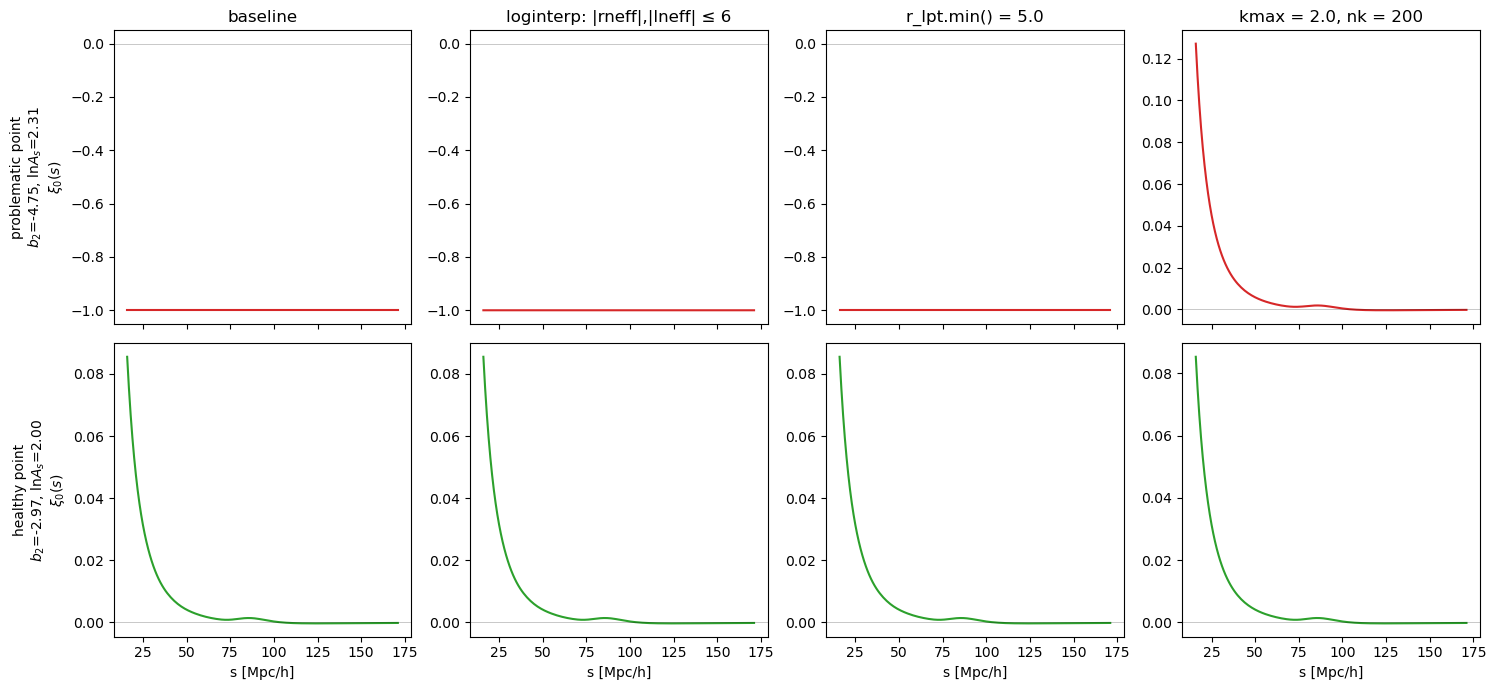

In [52]:
import copy
import numpy as np
import matplotlib.pyplot as plt

import velocileptors.Utils.loginterp as _loginterp_mod
from velocileptors.Utils.loginterp import loginterp as _loginterp_orig
from velocileptors.LPT import gaussian_streaming_model_fftw as _gsm_mod
from velocileptors.LPT import velocity_moments_fftw as _vm_mod
from velocileptors.LPT.gaussian_streaming_model_fftw import GaussianStreamingModel as _GSM_orig
from compact import lpt as _compact_lpt_mod

# --- pick test points from results ---
xi0_arr = np.array([r['xi0'] for r in results])
flat_score = np.mean(np.abs(xi0_arr + 1), axis=1)
noise_score = np.std(np.diff(xi0_arr, axis=1), axis=1)

bad_idx = int(np.argmin(flat_score))
healthy_mask = flat_score > 0.5
healthy_candidates = np.where(healthy_mask)[0]
healthy_idx = int(healthy_candidates[np.argmin(noise_score[healthy_candidates])])

def theta_of(idx):
    return [b1_fid, results[idx]['b2'], ombh2_fid, omch2_fid, h_fid, results[idx]['As']]

theta_bad = theta_of(bad_idx)
theta_healthy = theta_of(healthy_idx)

print(f"bad:     b2={results[bad_idx]['b2']:.3f}, lnAs={results[bad_idx]['y']:.3f}")
print(f"healthy: b2={results[healthy_idx]['b2']:.3f}, lnAs={results[healthy_idx]['y']:.3f}")

def predict_pair(csm_local):
    return (csm_local.predict(theta_bad, ells=(0, 2))[0],
            csm_local.predict(theta_healthy, ells=(0, 2))[0])

def verify_patches(loginterp_should_be_patched, gsm_should_be_patched):
    print("  loginterp bindings:")
    for name, mod in [("velocileptors.Utils.loginterp", _loginterp_mod),
                       ("gsm module", _gsm_mod),
                       ("velocity_moments module", _vm_mod)]:
        li = getattr(mod, 'loginterp', None)
        tag = "PATCHED" if li is not None and li.__qualname__ != 'loginterp' else "original"
        print(f"    {name}: {tag}")
    print("  GSM binding in compact.lpt:", 
          "PATCHED" if _compact_lpt_mod.GaussianStreamingModel is not _GSM_orig else "original")

# --- baseline ---
csm_base = CompactStreamingModel(z, cfg)
xi0_bad_base, xi0_healthy_base = predict_pair(csm_base)

# --- test 1: loginterp capped ---
def loginterp_capped(x, y, cap=6.0):
    from scipy.interpolate import make_interp_spline
    lp = 0
    while np.sign(y[lp]) != np.sign(y[lp+1]):
        lp += 1
    rp = len(x) - 1
    while np.sign(y[rp]) != np.sign(y[rp-1]):
        rp -= 1
    yint = make_interp_spline(np.log(x[lp:rp+1]), y[lp:rp+1], bc_type='natural')
    deriv = yint.derivative()
    lneff = np.clip(deriv(np.log(x[lp]))/y[lp], -cap, cap)
    rneff = np.clip(deriv(np.log(x[rp]))/y[rp], -cap, cap)
    return lambda xx: ((xx <= x[lp]) * y[lp] * np.nan_to_num((xx/x[lp])**lneff)
                     + (xx >= x[rp]) * y[rp] * np.nan_to_num((xx/x[rp])**rneff)
                     + (xx > x[lp]) * (xx < x[rp]) * yint(np.log(xx)))

_loginterp_mod.loginterp = loginterp_capped
_gsm_mod.loginterp = loginterp_capped
if hasattr(_vm_mod, 'loginterp'):
    _vm_mod.loginterp = loginterp_capped
try:
    print("test 1 (loginterp capped):")
    verify_patches(True, False)
    csm_cap = CompactStreamingModel(z, cfg)
    xi0_bad_cap, xi0_healthy_cap = predict_pair(csm_cap)
finally:
    _loginterp_mod.loginterp = _loginterp_orig
    _gsm_mod.loginterp = _loginterp_orig
    if hasattr(_vm_mod, 'loginterp'):
        _vm_mod.loginterp = _loginterp_orig

# --- test 2: raise r_lpt.min() ---
cfg_r = copy.copy(cfg)
new_r_lpt_min = 5.0
cfg_r.r_lpt = cfg.r_lpt[cfg.r_lpt >= new_r_lpt_min]
csm_r = CompactStreamingModel(z, cfg_r)
xi0_bad_r, xi0_healthy_r = predict_pair(csm_r)

# --- test 3: raise kmax ---
class _GSM_highkmax(_GSM_orig):
    def __init__(self, *args, **kwargs):
        kwargs.setdefault('kmax', 2.0)
        kwargs.setdefault('nk', 200)
        super().__init__(*args, **kwargs)

_gsm_mod.GaussianStreamingModel = _GSM_highkmax
_compact_lpt_mod.GaussianStreamingModel = _GSM_highkmax
try:
    print("test 3 (kmax=2.0):")
    verify_patches(False, True)
    csm_k = CompactStreamingModel(z, cfg)
    xi0_bad_k, xi0_healthy_k = predict_pair(csm_k)
finally:
    _gsm_mod.GaussianStreamingModel = _GSM_orig
    _compact_lpt_mod.GaussianStreamingModel = _GSM_orig

# --- plot ---
fig, axes = plt.subplots(2, 4, figsize=(15, 7), sharex=True)
titles = [
    "baseline",
    "loginterp: |rneff|,|lneff| ≤ 6",
    f"r_lpt.min() = {new_r_lpt_min}",
    "kmax = 2.0, nk = 200",
]
xi0_bad_all = [xi0_bad_base, xi0_bad_cap, xi0_bad_r, xi0_bad_k]
xi0_healthy_all = [xi0_healthy_base, xi0_healthy_cap, xi0_healthy_r, xi0_healthy_k]

for j, (title, xi0_bad, xi0_healthy) in enumerate(zip(titles, xi0_bad_all, xi0_healthy_all)):
    axes[0, j].plot(cfg.r, xi0_bad, color='C3')
    axes[0, j].axhline(0, color='k', lw=0.5, alpha=0.3)
    axes[0, j].set_title(title)

    axes[1, j].plot(cfg.r, xi0_healthy, color='C2')
    axes[1, j].axhline(0, color='k', lw=0.5, alpha=0.3)
    axes[1, j].set_xlabel('s [Mpc/h]')

axes[0, 0].set_ylabel(f"problematic point\n$b_2$={results[bad_idx]['b2']:.2f}, ln$A_s$={results[bad_idx]['y']:.2f}\n"+r"$\xi_0(s)$")
axes[1, 0].set_ylabel(f"healthy point\n$b_2$={results[healthy_idx]['b2']:.2f}, ln$A_s$={results[healthy_idx]['y']:.2f}\n"+r"$\xi_0(s)$")

fig.tight_layout()
plt.show()

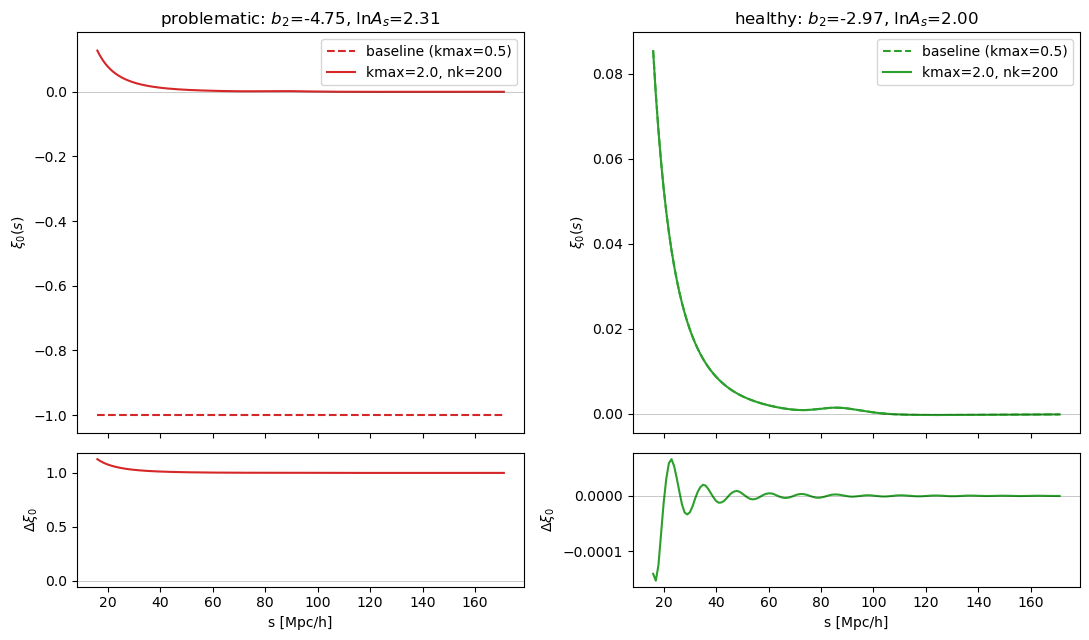

healthy max |Δξ_0 / ξ_0|: 10.202%


In [54]:
# using xi0_bad_base, xi0_bad_k, xi0_healthy_base, xi0_healthy_k from the previous run

fig, axes = plt.subplots(2, 2, figsize=(11, 6.5), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1]})

# top row: xi_0 curves
axes[0, 0].plot(cfg.r, xi0_bad_base, color='C3', linestyle='--', label='baseline (kmax=0.5)')
axes[0, 0].plot(cfg.r, xi0_bad_k, color='C3', label='kmax=2.0, nk=200')
axes[0, 0].axhline(0, color='k', lw=0.5, alpha=0.3)
axes[0, 0].set(title=f"problematic: $b_2$={results[bad_idx]['b2']:.2f}, ln$A_s$={results[bad_idx]['y']:.2f}",
                ylabel=r'$\xi_0(s)$')
axes[0, 0].legend()

axes[0, 1].plot(cfg.r, xi0_healthy_base, color='C2', linestyle='--', label='baseline (kmax=0.5)')
axes[0, 1].plot(cfg.r, xi0_healthy_k, color='C2', label='kmax=2.0, nk=200')
axes[0, 1].axhline(0, color='k', lw=0.5, alpha=0.3)
axes[0, 1].set(title=f"healthy: $b_2$={results[healthy_idx]['b2']:.2f}, ln$A_s$={results[healthy_idx]['y']:.2f}",
                ylabel=r'$\xi_0(s)$')
axes[0, 1].legend()

# bottom row: residuals (kmax=2.0 - baseline)
axes[1, 0].plot(cfg.r, xi0_bad_k - xi0_bad_base, color='C3')
axes[1, 0].axhline(0, color='k', lw=0.5, alpha=0.3)
axes[1, 0].set(xlabel='s [Mpc/h]', ylabel=r'$\Delta \xi_0$')

axes[1, 1].plot(cfg.r, xi0_healthy_k - xi0_healthy_base, color='C2')
axes[1, 1].axhline(0, color='k', lw=0.5, alpha=0.3)
axes[1, 1].set(xlabel='s [Mpc/h]', ylabel=r'$\Delta \xi_0$')

fig.tight_layout()
plt.show()

def rel_diff(a, b):
    denom = np.where(np.abs(b) > 1e-10, b, np.nan)
    return np.nanmax(np.abs((a - b) / denom))

print(f"healthy max |Δξ_0 / ξ_0|: {rel_diff(xi0_healthy_k, xi0_healthy_base):.3%}")

/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in power
  + (xx >= x[rp]) * y[rp]* np.nan_to_num((xx/x[rp])**rneff) \
/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in power
  + (xx >= x[rp]) * y[rp]* np.nan_to_num((xx/x[rp])**rneff) \
/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in power
  + (xx >= x[rp]) * y[rp]* np.nan_to_num((xx/x[rp])**rneff) \
/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in power
  + (xx >= x[rp]) * y[rp]* np.nan_to_num((xx/x[rp])**rneff) \
/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in pow

baseline (kmax=0.5): 427 / 3600 fail
kmax=2.0:            82 / 3600 fail
cleared by fix:      427
newly failing:       82
persistent fails:    0


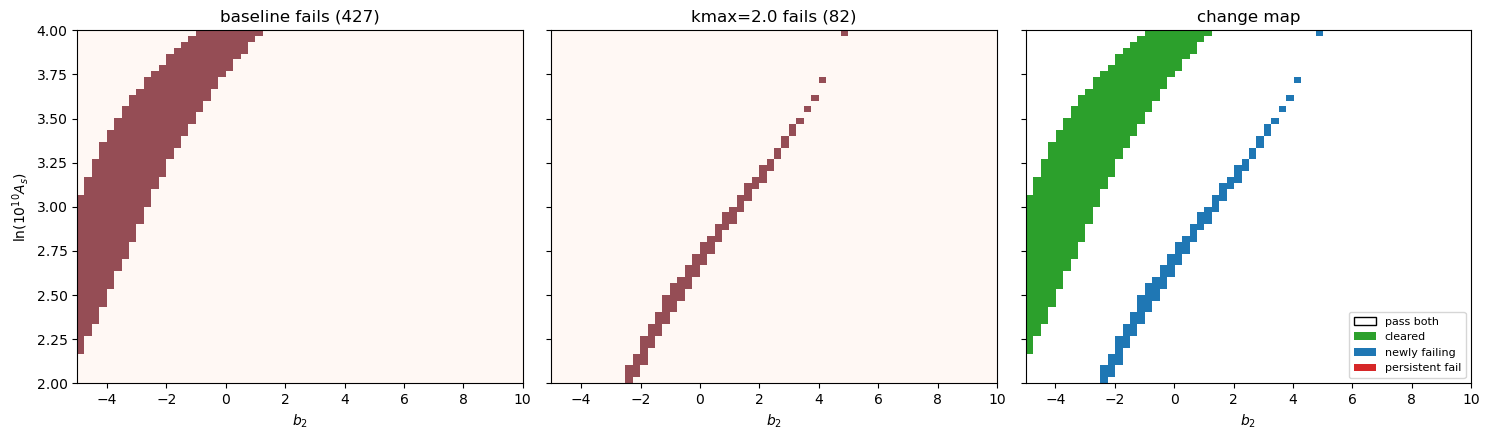

In [55]:
import os
for v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ[v] = "1"

from joblib import Parallel, delayed
import psutil

def check_point_kmax2(b2v, lnAs, nice=10):
    psutil.Process().nice(nice)
    As_v = np.exp(lnAs) / 1e10
    Plin_v = Plin_ref * (As_v / As_ref)

    g = GaussianStreamingModel(k_ref, Plin_v, kmax=2.0, nk=200)
    g.convert_sigma_bases()
    g.compute_cumulants(b1_fid, b2v, *np.zeros(7))
    return np.abs(g.veft).max()

pairs = [(b2v, lnAs) for lnAs in lnAs_grid for b2v in b2_grid]
scan_kmax2 = Parallel(n_jobs=80, batch_size=1)(
    delayed(check_point_kmax2)(b2v, lnAs) for b2v, lnAs in pairs
)
veft_max_kmax2 = np.array(scan_kmax2).reshape(len(lnAs_grid), len(b2_grid))
fail_kmax2 = veft_max_kmax2 > 1e4

# --- summary numbers ---
print(f"baseline (kmax=0.5): {fail.sum()} / {fail.size} fail")
print(f"kmax=2.0:            {fail_kmax2.sum()} / {fail_kmax2.size} fail")
print(f"cleared by fix:      {(fail & ~fail_kmax2).sum()}")
print(f"newly failing:       {(~fail & fail_kmax2).sum()}")
print(f"persistent fails:    {(fail & fail_kmax2).sum()}")

# --- diagnostic plot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
extent = [b2_grid.min(), b2_grid.max(), lnAs_grid.min(), lnAs_grid.max()]

axes[0].imshow(fail, extent=extent, aspect='auto', origin='lower', cmap='Reds', alpha=0.7)
axes[0].set(title=f"baseline fails ({fail.sum()})",
             xlabel=r'$b_2$', ylabel=r'$\ln(10^{10} A_s)$')

axes[1].imshow(fail_kmax2, extent=extent, aspect='auto', origin='lower', cmap='Reds', alpha=0.7)
axes[1].set(title=f"kmax=2.0 fails ({fail_kmax2.sum()})", xlabel=r'$b_2$')

# category map: 0=pass both, 1=cleared by fix, 2=newly failing, 3=persistent
cat = np.zeros_like(fail, dtype=int)
cat[fail & ~fail_kmax2] = 1
cat[~fail & fail_kmax2] = 2
cat[fail & fail_kmax2] = 3
from matplotlib.colors import ListedColormap
cmap = ListedColormap(['white', 'C2', 'C0', 'C3'])
im = axes[2].imshow(cat, extent=extent, aspect='auto', origin='lower', cmap=cmap, vmin=0, vmax=3)
axes[2].set(title="change map", xlabel=r'$b_2$')

# manual legend for the category map
from matplotlib.patches import Patch
handles = [Patch(facecolor='white', edgecolor='k', label='pass both'),
           Patch(facecolor='C2', label='cleared'),
           Patch(facecolor='C0', label='newly failing'),
           Patch(facecolor='C3', label='persistent fail')]
axes[2].legend(handles=handles, loc='lower right', fontsize=8)

fig.tight_layout()
plt.show()

scanning kmax=2.0, nk=200...


/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in power
  + (xx >= x[rp]) * y[rp]* np.nan_to_num((xx/x[rp])**rneff) \
/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in power
  + (xx >= x[rp]) * y[rp]* np.nan_to_num((xx/x[rp])**rneff) \
/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in power
  + (xx >= x[rp]) * y[rp]* np.nan_to_num((xx/x[rp])**rneff) \
/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in power
  + (xx >= x[rp]) * y[rp]* np.nan_to_num((xx/x[rp])**rneff) \
/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in pow

  82 fails
scanning kmax=5.0, nk=400...


/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in power
  + (xx >= x[rp]) * y[rp]* np.nan_to_num((xx/x[rp])**rneff) \
/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in power
  + (xx >= x[rp]) * y[rp]* np.nan_to_num((xx/x[rp])**rneff) \
/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in power
  + (xx >= x[rp]) * y[rp]* np.nan_to_num((xx/x[rp])**rneff) \
/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in power
  + (xx >= x[rp]) * y[rp]* np.nan_to_num((xx/x[rp])**rneff) \
/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in pow

  25 fails
scanning kmax=10.0, nk=800...


/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in power
  + (xx >= x[rp]) * y[rp]* np.nan_to_num((xx/x[rp])**rneff) \
/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in power
  + (xx >= x[rp]) * y[rp]* np.nan_to_num((xx/x[rp])**rneff) \
/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in power
  + (xx >= x[rp]) * y[rp]* np.nan_to_num((xx/x[rp])**rneff) \
/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in power
  + (xx >= x[rp]) * y[rp]* np.nan_to_num((xx/x[rp])**rneff) \


  9 fails

transitions vs baseline (kmax=0.5):
  kmax=2.0: 82 fails | cleared 427, newly failing 82, persistent 0
  kmax=5.0: 25 fails | cleared 427, newly failing 25, persistent 0
  kmax=10.0: 9 fails | cleared 427, newly failing 9, persistent 0


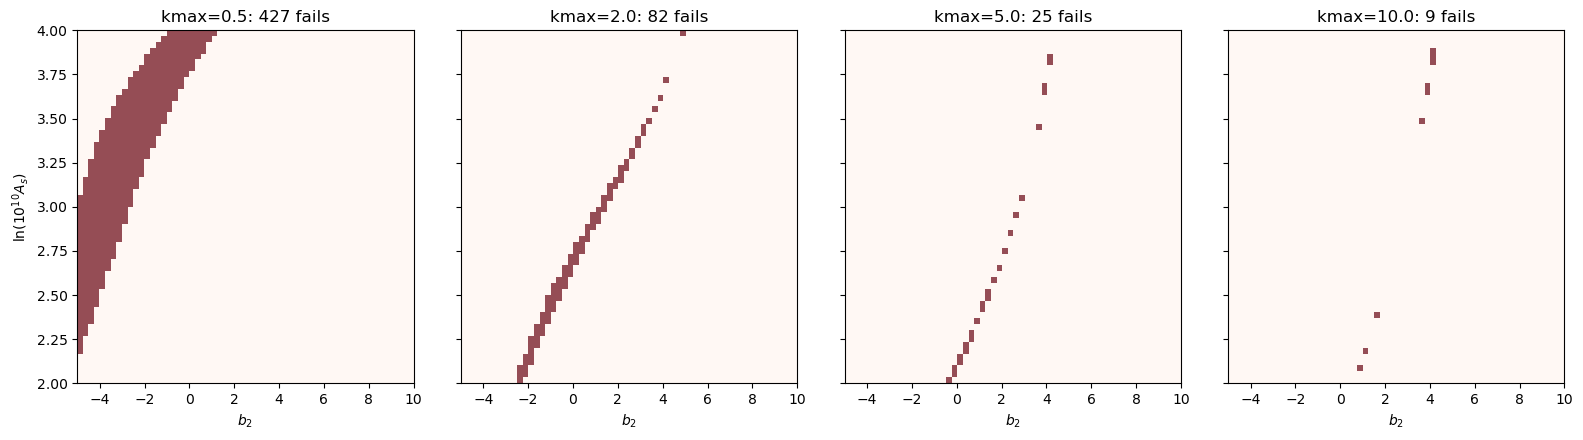

In [56]:
kmax_values = [2.0, 5.0, 10.0]
nk_values = [200, 400, 800]   # scale roughly with log(kmax/kmin) to keep k-resolution similar

def check_at_kmax(b2v, lnAs, kmax_v, nk_v, nice=10):
    psutil.Process().nice(nice)
    As_v = np.exp(lnAs) / 1e10
    Plin_v = Plin_ref * (As_v / As_ref)
    g = GaussianStreamingModel(k_ref, Plin_v, kmax=kmax_v, nk=nk_v)
    g.convert_sigma_bases()
    g.compute_cumulants(b1_fid, b2v, *np.zeros(7))
    return np.abs(g.veft).max()

fail_maps = {0.5: fail}  # existing baseline
veft_max_maps = {0.5: veft_max_grid if 'veft_max_grid' in dir() else None}

for kmax_v, nk_v in zip(kmax_values, nk_values):
    print(f"scanning kmax={kmax_v}, nk={nk_v}...")
    scan = Parallel(n_jobs=80, batch_size=1)(
        delayed(check_at_kmax)(b2v, lnAs, kmax_v, nk_v) for b2v, lnAs in pairs
    )
    veft_max_maps[kmax_v] = np.array(scan).reshape(len(lnAs_grid), len(b2_grid))
    fail_maps[kmax_v] = veft_max_maps[kmax_v] > 1e4
    print(f"  {fail_maps[kmax_v].sum()} fails")

# --- summary vs baseline ---
print("\ntransitions vs baseline (kmax=0.5):")
for k in kmax_values:
    fb = fail_maps[k]
    print(f"  kmax={k}: {fb.sum()} fails | "
          f"cleared {(fail & ~fb).sum()}, "
          f"newly failing {(~fail & fb).sum()}, "
          f"persistent {(fail & fb).sum()}")

# --- plot: fail maps side by side ---
n_cols = len(fail_maps)
fig, axes = plt.subplots(1, n_cols, figsize=(4*n_cols, 4.5), sharex=True, sharey=True)
extent = [b2_grid.min(), b2_grid.max(), lnAs_grid.min(), lnAs_grid.max()]

for ax, (k, fmap) in zip(axes, sorted(fail_maps.items())):
    ax.imshow(fmap, extent=extent, aspect='auto', origin='lower', cmap='Reds', alpha=0.7)
    ax.set(title=f"kmax={k}: {fmap.sum()} fails", xlabel=r'$b_2$')
axes[0].set_ylabel(r'$\ln(10^{10} A_s)$')

fig.tight_layout()
plt.show()

scanning kmax=0.1, nk=50...


/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in power
  + (xx >= x[rp]) * y[rp]* np.nan_to_num((xx/x[rp])**rneff) \
/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in power
  + (xx >= x[rp]) * y[rp]* np.nan_to_num((xx/x[rp])**rneff) \
/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in power
  + (xx >= x[rp]) * y[rp]* np.nan_to_num((xx/x[rp])**rneff) \
/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in power
  + (xx >= x[rp]) * y[rp]* np.nan_to_num((xx/x[rp])**rneff) \
/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in pow

scanning kmax=0.25, nk=75...


/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in power
  + (xx >= x[rp]) * y[rp]* np.nan_to_num((xx/x[rp])**rneff) \
/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in power
  + (xx >= x[rp]) * y[rp]* np.nan_to_num((xx/x[rp])**rneff) \
/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in power
  + (xx >= x[rp]) * y[rp]* np.nan_to_num((xx/x[rp])**rneff) \
/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in power
  + (xx >= x[rp]) * y[rp]* np.nan_to_num((xx/x[rp])**rneff) \
/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in pow

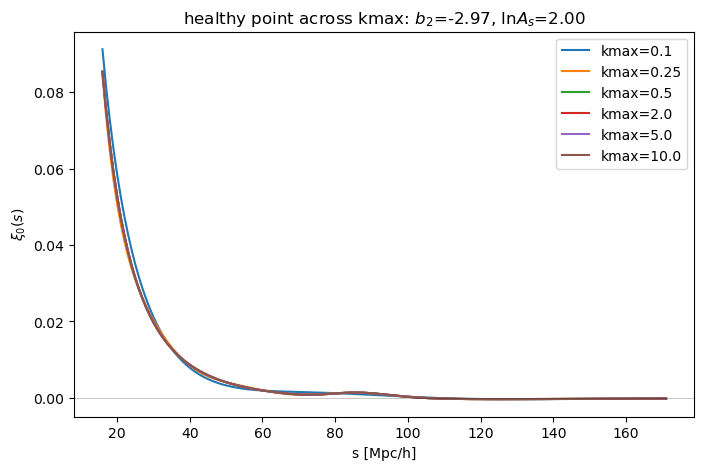

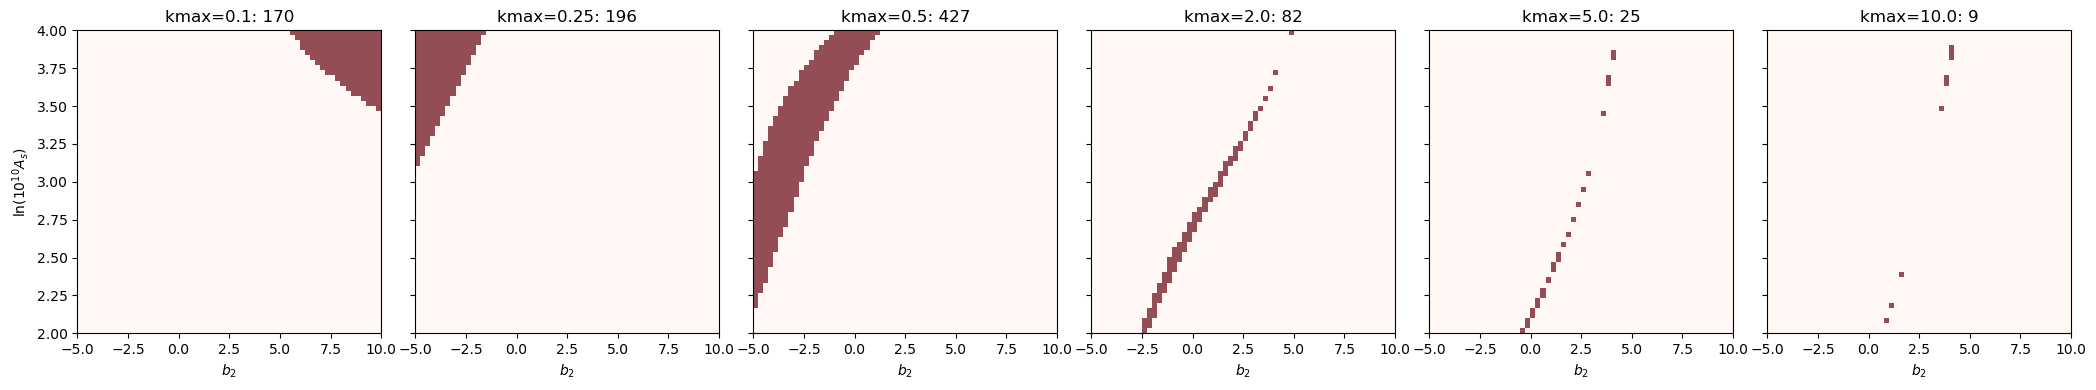

In [57]:
kmax_low = [0.1, 0.25]
nk_low = [50, 75]

for kmax_v, nk_v in zip(kmax_low, nk_low):
    print(f"scanning kmax={kmax_v}, nk={nk_v}...")
    scan = Parallel(n_jobs=80, batch_size=1)(
        delayed(check_at_kmax)(b2v, lnAs, kmax_v, nk_v) for b2v, lnAs in pairs
    )
    veft_max_maps[kmax_v] = np.array(scan).reshape(len(lnAs_grid), len(b2_grid))
    fail_maps[kmax_v] = veft_max_maps[kmax_v] > 1e4

# check healthy-point stability across all kmax values
theta_healthy_full = [b1_fid, results[healthy_idx]['b2'], ombh2_fid, omch2_fid, h_fid, results[healthy_idx]['As']]
xi0_healthy_by_kmax = {}
for k in sorted(fail_maps.keys()):
    # need to patch as before per-kmax
    class _GSM_k(_GSM_orig):
        _kmax_v = k
        _nk_v = {0.1: 50, 0.25: 75, 0.5: 100, 2.0: 200, 5.0: 400, 10.0: 800}[k]
        def __init__(self, *args, **kwargs):
            kwargs.setdefault('kmax', self._kmax_v)
            kwargs.setdefault('nk', self._nk_v)
            super().__init__(*args, **kwargs)
    _gsm_mod.GaussianStreamingModel = _GSM_k
    _compact_lpt_mod.GaussianStreamingModel = _GSM_k
    try:
        csm_local = CompactStreamingModel(z, cfg)
        xi0_healthy_by_kmax[k] = csm_local.predict(theta_healthy_full, ells=(0, 2))[0]
    finally:
        _gsm_mod.GaussianStreamingModel = _GSM_orig
        _compact_lpt_mod.GaussianStreamingModel = _GSM_orig

# plot healthy xi_0 across all kmax
fig, ax = plt.subplots(figsize=(8, 5))
for k in sorted(xi0_healthy_by_kmax):
    ax.plot(cfg.r, xi0_healthy_by_kmax[k], label=f'kmax={k}')
ax.axhline(0, color='k', lw=0.5, alpha=0.3)
ax.set(xlabel='s [Mpc/h]', ylabel=r'$\xi_0(s)$',
       title=f"healthy point across kmax: $b_2$={results[healthy_idx]['b2']:.2f}, ln$A_s$={results[healthy_idx]['y']:.2f}")
ax.legend()
plt.show()

# also show fail-region maps for all kmax
kmax_all = sorted(fail_maps.keys())
n = len(kmax_all)
fig, axes = plt.subplots(1, n, figsize=(3.5*n, 4), sharex=True, sharey=True)
for ax, k in zip(axes, kmax_all):
    ax.imshow(fail_maps[k], extent=extent, aspect='auto', origin='lower', cmap='Reds', alpha=0.7)
    ax.set(title=f"kmax={k}: {fail_maps[k].sum()}", xlabel=r'$b_2$')
axes[0].set_ylabel(r'$\ln(10^{10} A_s)$')
plt.tight_layout()
plt.show()

In [63]:
fail_maps[10].shape

(60, 60)

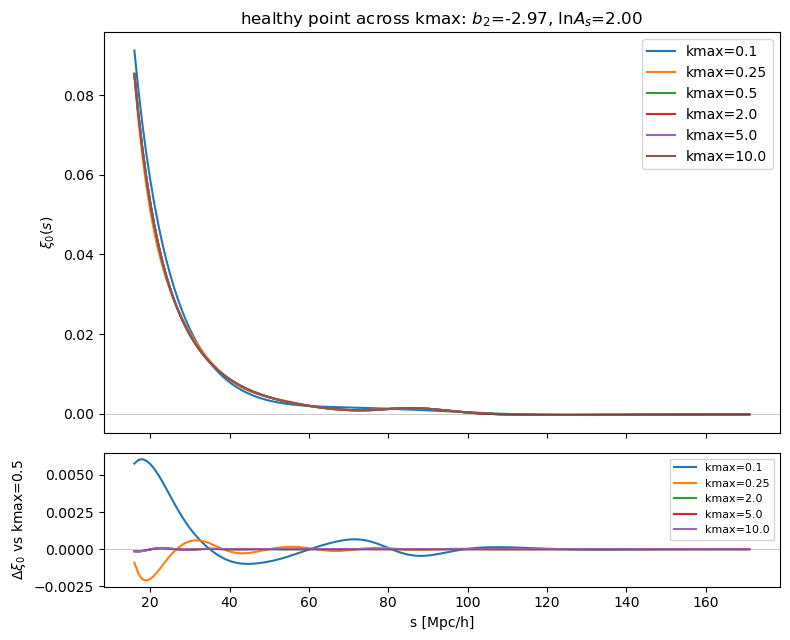

kmax=0.1: max |Δξ_0|=6.06e-03, max |Δξ_0/ξ_0|=1013.264%
kmax=0.25: max |Δξ_0|=2.12e-03, max |Δξ_0/ξ_0|=11.801%
kmax=2.0: max |Δξ_0|=1.53e-04, max |Δξ_0/ξ_0|=10.202%
kmax=5.0: max |Δξ_0|=1.54e-04, max |Δξ_0/ξ_0|=11.087%
kmax=10.0: max |Δξ_0|=1.54e-04, max |Δξ_0/ξ_0|=10.352%


In [59]:
# uses xi0_healthy_by_kmax from the previous sweep
baseline = xi0_healthy_by_kmax[0.5]

fig, axes = plt.subplots(2, 1, figsize=(8, 6.5), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1]})

for k in sorted(xi0_healthy_by_kmax):
    axes[0].plot(cfg.r, xi0_healthy_by_kmax[k], label=f'kmax={k}')
    if k != 0.5:
        axes[1].plot(cfg.r, xi0_healthy_by_kmax[k] - baseline, label=f'kmax={k}')

axes[0].axhline(0, color='k', lw=0.5, alpha=0.3)
axes[0].set(ylabel=r'$\xi_0(s)$',
             title=f"healthy point across kmax: $b_2$={results[healthy_idx]['b2']:.2f}, ln$A_s$={results[healthy_idx]['y']:.2f}")
axes[0].legend()

axes[1].axhline(0, color='k', lw=0.5, alpha=0.3)
axes[1].set(xlabel='s [Mpc/h]', ylabel=r'$\Delta \xi_0$ vs kmax=0.5')
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

for k in sorted(xi0_healthy_by_kmax):
    if k == 0.5:
        continue
    diff = xi0_healthy_by_kmax[k] - baseline
    print(f"kmax={k}: max |Δξ_0|={np.abs(diff).max():.2e}, "
          f"max |Δξ_0/ξ_0|={np.nanmax(np.abs(diff/np.where(np.abs(baseline)>1e-10, baseline, np.nan))):.3%}")

scanning kmax=10.0, nk=100...


/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in power
  + (xx >= x[rp]) * y[rp]* np.nan_to_num((xx/x[rp])**rneff) \
/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in power
  + (xx >= x[rp]) * y[rp]* np.nan_to_num((xx/x[rp])**rneff) \
/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in power
  + (xx >= x[rp]) * y[rp]* np.nan_to_num((xx/x[rp])**rneff) \
/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/LPT/cleft_fftw.py:125: RuntimeWarning: overflow encountered in exp
  expon = np.exp(-0.5*ksq * (self.XYlin - self.sigma))
/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/LPT/cleft_fftw.py:126: RuntimeWarning: overflow encountered in expm1
  expo

kmax=10, nk=100:  6 fails
kmax=10, nk=800:  9 fails  (previous)
kmax=0.5 baseline: 427 fails


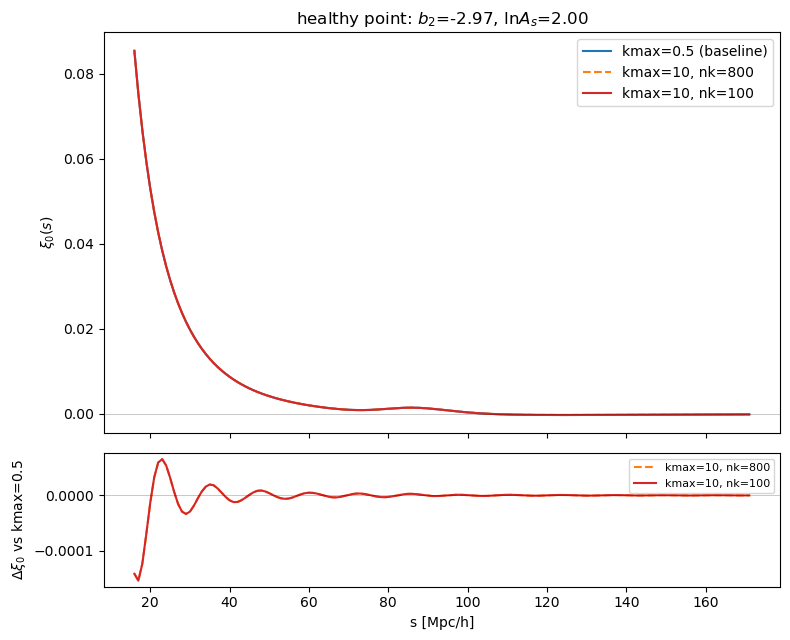

kmax=10, nk=800 vs baseline: max |Δξ_0|=1.54e-04, max |Δξ_0/ξ_0|=10.352%
kmax=10, nk=100 vs baseline: max |Δξ_0|=1.54e-04, max |Δξ_0/ξ_0|=10.352%


In [68]:
kmax_v = 10.0
nk_v = 100

# --- grid scan at kmax=10, nk=100 ---
def check_at_kmax_nk100(b2v, lnAs, nice=10):
    psutil.Process().nice(nice)
    As_v = np.exp(lnAs) / 1e10
    Plin_v = Plin_ref * (As_v / As_ref)
    g = GaussianStreamingModel(k_ref, Plin_v, kmax=kmax_v, nk=nk_v)
    g.convert_sigma_bases()
    g.compute_cumulants(b1_fid, b2v, *np.zeros(7))
    return np.abs(g.veft).max()

print(f"scanning kmax={kmax_v}, nk={nk_v}...")
scan = Parallel(n_jobs=80, batch_size=1)(
    delayed(check_at_kmax_nk100)(b2v, lnAs) for b2v, lnAs in pairs
)
veft_max_k10_nk100 = np.array(scan).reshape(len(lnAs_grid), len(b2_grid))
fail_k10_nk100 = veft_max_k10_nk100 > 1e4

print(f"kmax=10, nk=100:  {fail_k10_nk100.sum()} fails")
print(f"kmax=10, nk=800:  {fail_maps[10.0].sum()} fails  (previous)")
print(f"kmax=0.5 baseline: {fail.sum()} fails")

# --- healthy point prediction at kmax=10, nk=100 ---
class _GSM_k10_nk100(_GSM_orig):
    def __init__(self, *args, **kwargs):
        kwargs.setdefault('kmax', kmax_v)
        kwargs.setdefault('nk', nk_v)
        super().__init__(*args, **kwargs)

theta_healthy_full = [b1_fid, results[healthy_idx]['b2'], ombh2_fid, omch2_fid,
                       h_fid, results[healthy_idx]['As']]

_gsm_mod.GaussianStreamingModel = _GSM_k10_nk100
_compact_lpt_mod.GaussianStreamingModel = _GSM_k10_nk100
try:
    csm_local = CompactStreamingModel(z, cfg)
    xi0_k10_nk100 = csm_local.predict(theta_healthy_full, ells=(0, 2))[0]
finally:
    _gsm_mod.GaussianStreamingModel = _GSM_orig
    _compact_lpt_mod.GaussianStreamingModel = _GSM_orig

# --- plot: xi0 + residual against baseline kmax=0.5 ---
baseline = xi0_healthy_by_kmax[0.5]

fig, axes = plt.subplots(2, 1, figsize=(8, 6.5), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1]})

axes[0].plot(cfg.r, baseline, label='kmax=0.5 (baseline)', color='C0')
axes[0].plot(cfg.r, xi0_healthy_by_kmax[10.0], label='kmax=10, nk=800', color='C1', linestyle='--')
axes[0].plot(cfg.r, xi0_k10_nk100, label='kmax=10, nk=100', color='C3')
axes[0].axhline(0, color='k', lw=0.5, alpha=0.3)
axes[0].set(ylabel=r'$\xi_0(s)$',
             title=f"healthy point: $b_2$={results[healthy_idx]['b2']:.2f}, ln$A_s$={results[healthy_idx]['y']:.2f}")
axes[0].legend()

axes[1].plot(cfg.r, xi0_healthy_by_kmax[10.0] - baseline, label='kmax=10, nk=800', color='C1', linestyle='--')
axes[1].plot(cfg.r, xi0_k10_nk100 - baseline, label='kmax=10, nk=100', color='C3')
axes[1].axhline(0, color='k', lw=0.5, alpha=0.3)
axes[1].set(xlabel='s [Mpc/h]', ylabel=r'$\Delta \xi_0$ vs kmax=0.5')
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

def rel_diff(a, b):
    denom = np.where(np.abs(b) > 1e-10, b, np.nan)
    return np.nanmax(np.abs((a - b) / denom))

print(f"kmax=10, nk=800 vs baseline: max |Δξ_0|={np.abs(xi0_healthy_by_kmax[10.0]-baseline).max():.2e}, "
      f"max |Δξ_0/ξ_0|={rel_diff(xi0_healthy_by_kmax[10.0], baseline):.3%}")
print(f"kmax=10, nk=100 vs baseline: max |Δξ_0|={np.abs(xi0_k10_nk100-baseline).max():.2e}, "
      f"max |Δξ_0/ξ_0|={rel_diff(xi0_k10_nk100, baseline):.3%}")

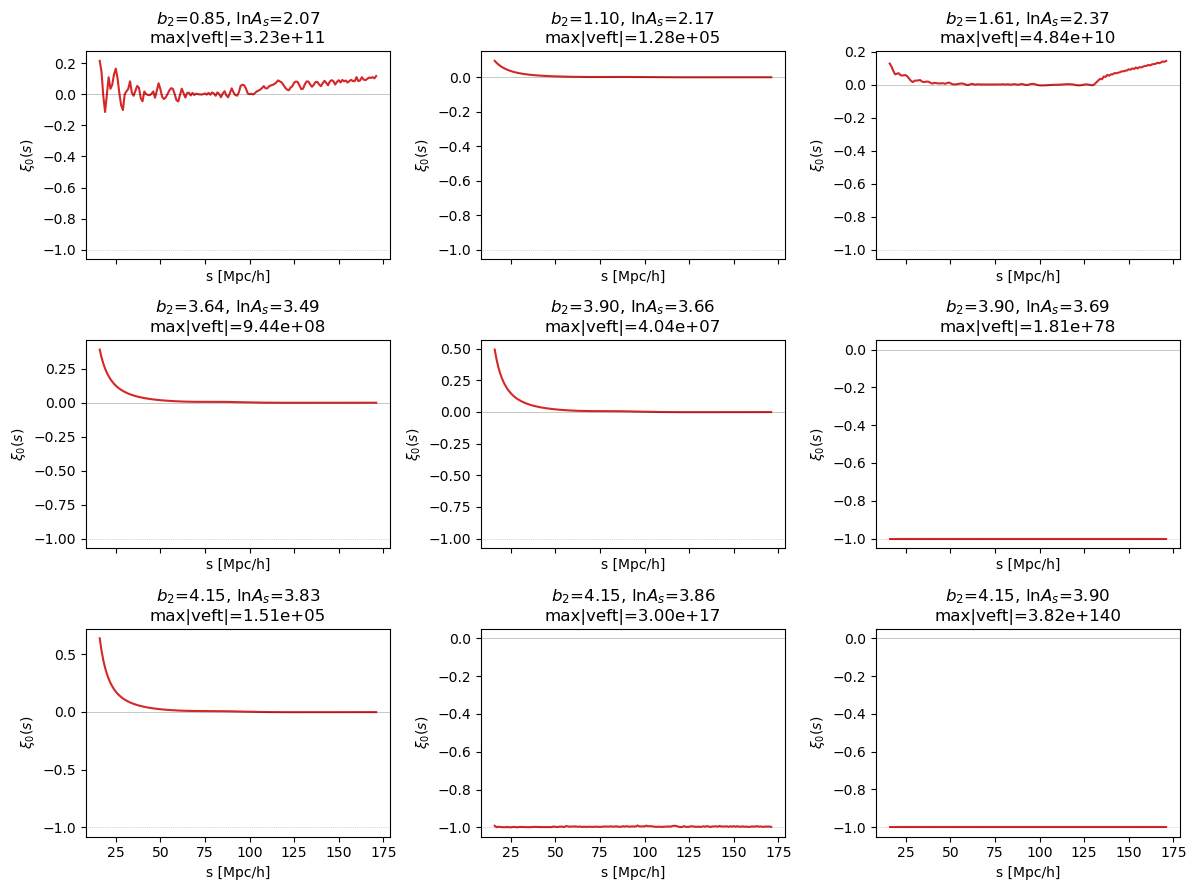


Failure characterization:
  b2=+0.85, lnAs=2.07: veft_max=3.23e+11, other
  b2=+1.10, lnAs=2.17: veft_max=1.28e+05, other
  b2=+1.61, lnAs=2.37: veft_max=4.84e+10, other
  b2=+3.64, lnAs=3.49: veft_max=9.44e+08, other
  b2=+3.90, lnAs=3.66: veft_max=4.04e+07, other
  b2=+3.90, lnAs=3.69: veft_max=1.81e+78, pinned
  b2=+4.15, lnAs=3.83: veft_max=1.51e+05, other
  b2=+4.15, lnAs=3.86: veft_max=3.00e+17, pinned
  b2=+4.15, lnAs=3.90: veft_max=3.82e+140, pinned


In [67]:
# assumes fail_maps[10.0] is the failing grid from the kmax=10 scan
fail_pts = np.array(np.where(fail_maps[10.0])).T   # (N, 2), each row [i_lnAs, i_b2]

# patch GSM to kmax=10 for these predictions
class _GSM_k10(_GSM_orig):
    def __init__(self, *args, **kwargs):
        kwargs.setdefault('kmax', 10.0)
        kwargs.setdefault('nk', 800)
        super().__init__(*args, **kwargs)

_gsm_mod.GaussianStreamingModel = _GSM_k10
_compact_lpt_mod.GaussianStreamingModel = _GSM_k10

fail_predictions = []
try:
    csm_k10 = CompactStreamingModel(z, cfg)
    for i_lnAs, i_b2 in fail_pts:
        b2v = b2_grid[i_b2]
        lnAsv = lnAs_grid[i_lnAs]
        As_v = np.exp(lnAsv) / 1e10
        theta = [b1_fid, b2v, ombh2_fid, omch2_fid, h_fid, As_v]
        multi = csm_k10.predict(theta, ells=(0, 2))
        fail_predictions.append(dict(b2=b2v, lnAs=lnAsv, xi0=multi[0], xi2=multi[1],
                                      veft_max=veft_max_maps[10.0][i_lnAs, i_b2]))
finally:
    _gsm_mod.GaussianStreamingModel = _GSM_orig
    _compact_lpt_mod.GaussianStreamingModel = _GSM_orig

# --- plot: one panel per failing point, xi_0 shown; label with (b2, lnAs, veft_max) ---
n = len(fail_predictions)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), sharex=True)
axes = np.atleast_2d(axes).flat

for ax, pred in zip(axes, fail_predictions):
    ax.plot(cfg.r, pred['xi0'], color='C3')
    ax.axhline(0, color='k', lw=0.5, alpha=0.3)
    ax.axhline(-1, color='k', lw=0.5, alpha=0.3, linestyle=':')
    ax.set(title=f"$b_2$={pred['b2']:.2f}, ln$A_s$={pred['lnAs']:.2f}\n"
                  f"max|veft|={pred['veft_max']:.2e}",
           xlabel='s [Mpc/h]', ylabel=r'$\xi_0(s)$')

for ax in list(axes)[n:]:
    ax.axis('off')

fig.tight_layout()
plt.show()

# --- summary table: how many pinned-at-1, how many noisy, veft_max distribution ---
print("\nFailure characterization:")
for pred in fail_predictions:
    pinned = np.mean(np.abs(pred['xi0'] + 1)) < 0.1
    noisy = np.std(np.diff(pred['xi0'])) > 0.05
    tag = 'pinned' if pinned else ('noisy' if noisy else 'other')
    print(f"  b2={pred['b2']:+.2f}, lnAs={pred['lnAs']:.2f}: veft_max={pred['veft_max']:.2e}, {tag}")

In [26]:
fail_pairs = [(B2.ravel()[i], LNAS.ravel()[i]) for i in np.flatnonzero(fail.ravel())]

import traceback

for b2v, lnAsv in fail_pairs:
    As_v = np.exp(lnAsv) / 1e10
    Plin_v = Plin_ref * (As_v / As_ref)

    g = GaussianStreamingModel(k_ref, Plin_v)
    g.convert_sigma_bases()

    with np.errstate(over='raise'):
        try:
            g.compute_cumulants(fixed[0], b2v, 0, 0, 0, 0, 0, 0, 0)
        except FloatingPointError:
            print(f"OVERFLOW at b2={b2v:.3f}, lnAs={lnAsv:.3f}")
            traceback.print_exc()
            break
else:
    print("no point in fail_pairs raised an overflow under errstate")

no point in fail_pairs raised an overflow under errstate


In [28]:
import traceback

for i, res in enumerate(results):
    b2v, As_v = res['b2'], res['As']
    cosmo = (h_fid, ombh2_fid, omch2_fid, As_v)
    lpt_pars = np.concatenate(([b1_fid, b2v], np.zeros(7)))

    with np.errstate(over='raise'):
      try:
          multi = csm.predict([b1_fid, b2v, ombh2_fid, omch2_fid, h_fid, As_v], ells=(0, 2))
      except FloatingPointError:
          print(f"OVERFLOW at idx={i}")
          traceback.print_exc()
else:
    print("no point in results raised an overflow under errstate")

no point in results raised an overflow under errstate


In [29]:
  import warnings

  for i, res in enumerate(results):
      b2v, As_v = res['b2'], res['As']
      cosmo = (h_fid, ombh2_fid, omch2_fid, As_v)
      lpt_pars = np.concatenate(([b1_fid, b2v], np.zeros(7)))

      with warnings.catch_warnings(record=True) as w:
          warnings.simplefilter("always")
          gli = GetLPTInputs(z, cosmo, lpt_pars)
          v_r = gli.pwv_mean(r_v, lpt_pars)
          if any("overflow" in str(warn.message) for warn in w):
              print(f"OVERFLOW WARNING at idx={i}, b2={b2v:.3f}, As={As_v:.4g}")
              break
  else:
      print("no warning caught in results")

no warning caught in results


In [ ]:
import traceback

for i, res in enumerate(results):
    b2v, As_v = res['b2'], res['As']
    cosmo = (h_fid, ombh2_fid, omch2_fid, As_v)
    lpt_pars = np.concatenate(([b1_fid, b2v], np.zeros(7)))

    with np.errstate(over='raise'):
        try:
            gli = GetLPTInputs(z, cosmo, lpt_pars)
            v_r = gli.pwv_mean(r_v, lpt_pars)
        except FloatingPointError:
            print(f"OVERFLOW at idx={i}, b2={b2v:.3f}, As={As_v:.4g}")
            traceback.print_exc()
            break
else:
    print("no point in results raised an overflow under errstate")

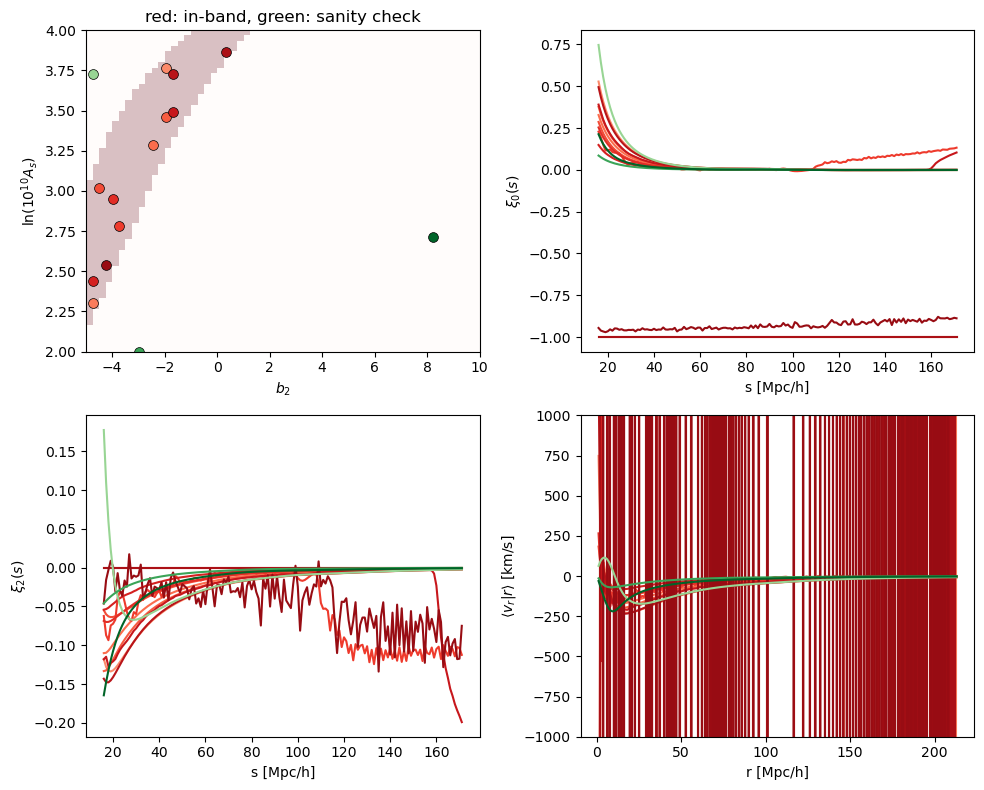

In [7]:
# --- step 4: plot ---
reds = plt.cm.Reds(np.linspace(0.4, 0.9, n_in))
greens = plt.cm.Greens(np.linspace(0.4, 0.9, n_out))
colors = np.concatenate([reds, greens])

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
ax_param, ax_xi0, ax_xi2, ax_vr = axes.flat

ax_param.imshow(fail, extent=[b2_grid.min(), b2_grid.max(), lnAs_grid.min(), lnAs_grid.max()],
                 aspect='auto', origin='lower', cmap='Reds', alpha=0.25)

for res, c in zip(results, colors):
    ax_param.scatter(res['b2'], res['y'], color=c, s=50, edgecolor='k', linewidth=0.5)
    ax_xi0.plot(cfg.r, res['xi0'], color=c)
    ax_xi2.plot(cfg.r, res['xi2'], color=c)
    ax_vr.plot(r_v, res['v_r'], color=c)

ax_param.set(xlabel=r'$b_2$', ylabel=r'$\ln(10^{10}A_s)$',
             title='red: in-band, green: sanity check')
ax_xi0.set(xlabel='s [Mpc/h]', ylabel=r'$\xi_0(s)$')
ax_xi2.set(xlabel='s [Mpc/h]', ylabel=r'$\xi_2(s)$')
ax_vr.set(xlabel='r [Mpc/h]', ylabel=r'$\langle v_r|r\rangle$ [km/s]', ylim=(-1000, 1000))

fig.tight_layout()
plt.show()

In [2]:
# ============================================================ 0. motivating issue
print("=" * 70)
print("0. THE MOTIVATING ISSUE")
print("=" * 70)

xi0 = xi[:, 0]
collapsed = (np.median(xi0, axis=1) < -0.5) | (np.abs(xi[:, 1]).max(axis=1) < 1e-8)
rough = np.abs(np.diff(xi0, n=2, axis=1)).mean(axis=1) / np.abs(xi0).mean(axis=1)
noisy = rough > 5 * np.median(rough[~collapsed])

print(f"{collapsed.sum()} collapsed (xi_0 flat at -1, higher multipoles ~0) "
      f"of {len(thetas)}")
print(f"{noisy.sum()} noisy (large second-difference relative to amplitude)")

BAD_IDX = 55
b1, b2, ob, oc, h, As = thetas[BAD_IDX]
print(f"\nworking example: index {BAD_IDX}")
print(f"  theta = b1={b1:.3f} b2={b2:+.3f} ob={ob:.4f} oc={oc:.4f} "
      f"h={h:.3f} lnAs={np.log(1e10*As):.3f}")
print(f"  median xi_0 = {np.median(xi0[BAD_IDX]):.3f}  "
      f"(a healthy value is O(0.01-1), not -1)")


0. THE MOTIVATING ISSUE
1687 collapsed (xi_0 flat at -1, higher multipoles ~0) of 65536
555 noisy (large second-difference relative to amplitude)

working example: index 55
  theta = b1=0.674 b2=-1.593 ob=0.0222 oc=0.1054 h=0.561 lnAs=3.398
  median xi_0 = -1.000  (a healthy value is O(0.01-1), not -1)


In [3]:

# ============================================================ 1. ruled out: sigma^2_12
print("\n" + "=" * 70)
print("1. RULED OUT -- sigma^2_12 going negative (Ramirez et al. eq 3.35-3.38)")
print("=" * 70)
print("""
Pv_compact (the compact velocity PDF) never references sigma^2_12 at all --
its width comes from sigma_mod_R, a separate empirical fit. The Ramirez et al.
regularization for a negative loop cumulant does not apply to this model.
No check to run; ruled out by reading Pv_compact's argument list.
""")



1. RULED OUT -- sigma^2_12 going negative (Ramirez et al. eq 3.35-3.38)

Pv_compact (the compact velocity PDF) never references sigma^2_12 at all --
its width comes from sigma_mod_R, a separate empirical fit. The Ramirez et al.
regularization for a negative loop cumulant does not apply to this model.
No check to run; ruled out by reading Pv_compact's argument list.



In [4]:
print("=" * 70)
print("2. RULED OUT -- (1 + xi_int) denominator in pwv_mean crossing zero")
print("=" * 70)
 
gli = GetLPTInputs(0.5, (h, ob, oc, As), np.concatenate(([b1, b2], np.zeros(7))))
gli.get_pklin_gsm()
gli.gsm.compute_cumulants(b1, b2, *np.zeros(7))   # populates xieft/veft; get_pklin_gsm alone does not
xi_int = np.interp(cfg.r_lpt, gli.gsm.rint, gli.gsm.xieft)
print(f"1 + xi_int range on this theta: [{(1+xi_int).min():.4f}, {(1+xi_int).max():.4f}]")
print("Never near zero -- pwv_mean's denominator is healthy. Ruled out.\n")
 

2. RULED OUT -- (1 + xi_int) denominator in pwv_mean crossing zero
1 + xi_int range on this theta: [0.9992, 11.4289]
Never near zero -- pwv_mean's denominator is healthy. Ruled out.



In [5]:

# ============================================================ 3. ruled out: FFTLog edge / r_lpt floor
print("=" * 70)
print("3. RULED OUT -- FFTLog ringing at small-r edge of velocileptors' grid")
print("=" * 70)

gli.gsm.compute_cumulants(b1, b2, *np.zeros(7))
r = gli.gsm.rint
print(f"veft near r_lpt[0]=1.0 (idx of closest rint point): "
      f"|veft| = {np.abs(gli.gsm.veft)[np.argmin(np.abs(r - 1.0))]:.3e}")
print("Still ~1e24+ even away from the r~0.1 grid edge -- raising r_lpt's")
print("floor does not fix it. Ruled out.\n")


3. RULED OUT -- FFTLog ringing at small-r edge of velocileptors' grid
veft near r_lpt[0]=1.0 (idx of closest rint point): |veft| = 1.292e+25
Still ~1e24+ even away from the r~0.1 grid edge -- raising r_lpt's
floor does not fix it. Ruled out.



In [6]:

# ============================================================ 4. ruled out: CAMB k-truncation
print("=" * 70)
print("4. RULED OUT -- hard k-space truncation feeding FFTLog")
print("=" * 70)

camb_pars = camb.set_params(H0=100.0*h, ombh2=ob, omch2=oc, As=As, ns=0.9649)
camb_pars.NonLinear = camb.model.NonLinear_none
camb_pars.set_matter_power(redshifts=[0.5], kmax=2*100.0*h)
results_wide = camb.get_results(camb_pars)
k_wide, _, pk_wide = results_wide.get_matter_power_spectrum(
    minkh=1e-5, maxkh=100.0, npoints=2048)

g_wide = GaussianStreamingModel(k_wide, pk_wide[0])
g_wide.convert_sigma_bases()
g_wide.compute_cumulants(b1, b2, *np.zeros(7))
print(f"|veft|max with kmax=100 (no warning, explicit Transfer.kmax): "
      f"{np.abs(g_wide.veft).max():.3e}")
print("Same order of magnitude as the default kmax -- not a truncation")
print("artifact. Ruled out.\n")


4. RULED OUT -- hard k-space truncation feeding FFTLog
|veft|max with kmax=100 (no warning, explicit Transfer.kmax): 1.243e+34
Same order of magnitude as the default kmax -- not a truncation
artifact. Ruled out.



In [9]:
# ============================================================ 5. confirmed: pointwise velocileptors failure
print("=" * 70)
print("5. CONFIRMED -- deterministic, pointwise failure in velocileptors' veft")
print("=" * 70)

healthy_idx = np.where(~collapsed & ~noisy)[0][0]
theta_good = thetas[healthy_idx]

n_steps = 11
print(f"Interpolating theta from index {healthy_idx} (healthy) to {BAD_IDX} (bad):")
for t in np.linspace(0, 1, n_steps):
    th = (1 - t) * theta_good + t * thetas[BAD_IDX]
    gli_t = GetLPTInputs(0.5, (th[4], th[2], th[3], th[5]),
                         np.concatenate((th[:2], np.zeros(7))))
    gli_t.get_pklin_gsm()
    gli_t.gsm.compute_cumulants(th[0], th[1], *np.zeros(7))
    print(f"  t={t:.2f}  |veft|max={np.abs(gli_t.gsm.veft).max():.3e}")

print("""
Smooth, monotonic decay right up to t just under 1, then an abrupt jump of
~30 orders of magnitude exactly at the target theta. Not a bounded failing
region and not a rough/noisy instability spread through parameter space --
a pointwise numerical failure. xieft stays well-behaved for the same theta
(check below), isolating the failure to velocileptors' velocity-moment
machinery specifically.
""")
print(f"  xieft max at bad theta: {np.abs(gli.gsm.xieft).max():.3e}  (healthy range)")


5. CONFIRMED -- deterministic, pointwise failure in velocileptors' veft
Interpolating theta from index 0 (healthy) to 55 (bad):
  t=0.00  |veft|max=5.355e+01
  t=0.10  |veft|max=4.593e+01
  t=0.20  |veft|max=3.870e+01
  t=0.30  |veft|max=3.192e+01
  t=0.40  |veft|max=2.566e+01
  t=0.50  |veft|max=2.003e+01
  t=0.60  |veft|max=1.514e+01
  t=0.70  |veft|max=1.107e+01
  t=0.80  |veft|max=7.880e+00
  t=0.90  |veft|max=5.553e+00
  t=1.00  |veft|max=8.100e+33

Smooth, monotonic decay right up to t just under 1, then an abrupt jump of
~30 orders of magnitude exactly at the target theta. Not a bounded failing
region and not a rough/noisy instability spread through parameter space --
a pointwise numerical failure. xieft stays well-behaved for the same theta
(check below), isolating the failure to velocileptors' velocity-moment
machinery specifically.

  xieft max at bad theta: 5.739e+01  (healthy range)


In [ ]:
b2_grid = np.linspace(-5, 10, 60)
lnAs_grid = np.linspace(2, 4, 60)
fail = np.zeros((len(lnAs_grid), len(b2_grid)), dtype=bool)

fixed = thetas[BAD_IDX].copy()   # hold b1, omega_b, omega_cdm, h fixed
for i, lnAs in enumerate(lnAs_grid):
    for j, b2v in enumerate(b2_grid):
        th = fixed.copy()
        th[1] = b2v
        th[5] = np.exp(lnAs) / 1e10
        gli_t = GetLPTInputs(0.5, (th[4], th[2], th[3], th[5]),
                             np.concatenate((th[:2], np.zeros(7))))
        gli_t.get_pklin_gsm()
        gli_t.gsm.compute_cumulants(th[0], th[1], *np.zeros(7))
        fail[i, j] = np.abs(gli_t.gsm.veft).max() > 1e4



/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in power
  + (xx >= x[rp]) * y[rp]* np.nan_to_num((xx/x[rp])**rneff) \


KeyboardInterrupt: 

In [8]:
import os
for v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ[v] = "1"

import numpy as np
from joblib import Parallel, delayed
import psutil

fixed = thetas[BAD_IDX].copy()
As_ref = fixed[5]

gli_ref = GetLPTInputs(0.5, (fixed[4], fixed[2], fixed[3], As_ref),
                       np.concatenate((fixed[:2], np.zeros(7))))
gli_ref.get_pklin_gsm()
k_ref, Plin_ref = gli_ref.klin, gli_ref.Plin   # one CAMB call for the whole grid

b2_grid = np.linspace(-5, 10, 60)
lnAs_grid = np.linspace(2, 4, 60)

def check_point(b2v, lnAs, nice=10):
    psutil.Process().nice(nice)
    As_v = np.exp(lnAs) / 1e10
    Plin_v = Plin_ref * (As_v / As_ref)     # rescale instead of rerunning CAMB

    g = GaussianStreamingModel(k_ref, Plin_v)
    g.convert_sigma_bases()
    g.compute_cumulants(fixed[0], b2v, *np.zeros(7))
    return np.abs(g.veft).max() > 1e4

pairs = [(b2v, lnAs) for lnAs in lnAs_grid for b2v in b2_grid]
results = Parallel(n_jobs=80, batch_size=1)(
    delayed(check_point)(b2v, lnAs) for b2v, lnAs in pairs)

fail = np.array(results, dtype=bool).reshape(len(lnAs_grid), len(b2_grid))

/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in power
  + (xx >= x[rp]) * y[rp]* np.nan_to_num((xx/x[rp])**rneff) \
/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in power
  + (xx >= x[rp]) * y[rp]* np.nan_to_num((xx/x[rp])**rneff) \
/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in power
  + (xx >= x[rp]) * y[rp]* np.nan_to_num((xx/x[rp])**rneff) \
/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in power
  + (xx >= x[rp]) * y[rp]* np.nan_to_num((xx/x[rp])**rneff) \
/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in pow

Text(0, 0.5, '$\\ln(10^{10}A_s)$')

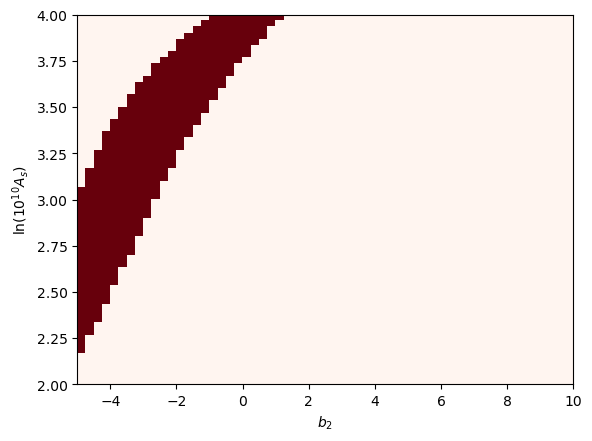

In [9]:
import matplotlib.pyplot as plt
plt.imshow(fail, extent=[-5, 10, 2, 4], aspect='auto', origin='lower', cmap='Reds')
plt.xlabel(r'$b_2$'); plt.ylabel(r'$\ln(10^{10}A_s)$')

In [11]:
lnAs_fixed = 3.0
b2_scan = np.linspace(-3, 1, 80)
names = ['V', 'Vdot', 'Vloop', 'U11dot', 'X10dot', 'Y10dot', 'Uloopdot']

for b2v in b2_scan:
    th = fixed.copy(); th[1] = b2v; th[5] = np.exp(lnAs_fixed)/1e10
    g = GaussianStreamingModel(k_ref, Plin_ref * (th[5]/As_ref))
    g.convert_sigma_bases()
    g.compute_cumulants(th[0], b2v, *np.zeros(7))
    vals = [np.abs(np.asarray(getattr(g, n))).max() for n in names]
    print(f"b2={b2v:+.3f}  " + "  ".join(f"{n}={v:.2e}" for n, v in zip(names, vals)))

b2=-3.000  V=3.36e-01  Vdot=3.74e+00  Vloop=2.81e+00  U11dot=2.50e+00  X10dot=2.82e+00  Y10dot=2.08e+00  Uloopdot=9.46e-01
b2=-2.949  V=3.36e-01  Vdot=3.74e+00  Vloop=2.81e+00  U11dot=2.50e+00  X10dot=2.82e+00  Y10dot=2.08e+00  Uloopdot=9.46e-01
b2=-2.899  V=3.36e-01  Vdot=3.74e+00  Vloop=2.81e+00  U11dot=2.50e+00  X10dot=2.82e+00  Y10dot=2.08e+00  Uloopdot=9.46e-01
b2=-2.848  V=3.36e-01  Vdot=3.74e+00  Vloop=2.81e+00  U11dot=2.50e+00  X10dot=2.82e+00  Y10dot=2.08e+00  Uloopdot=9.46e-01
b2=-2.797  V=3.36e-01  Vdot=3.74e+00  Vloop=2.81e+00  U11dot=2.50e+00  X10dot=2.82e+00  Y10dot=2.08e+00  Uloopdot=9.46e-01
b2=-2.747  V=3.36e-01  Vdot=3.74e+00  Vloop=2.81e+00  U11dot=2.50e+00  X10dot=2.82e+00  Y10dot=2.08e+00  Uloopdot=9.46e-01


/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/loginterp.py:44: RuntimeWarning: overflow encountered in power
  + (xx >= x[rp]) * y[rp]* np.nan_to_num((xx/x[rp])**rneff) \


b2=-2.696  V=3.36e-01  Vdot=3.74e+00  Vloop=2.81e+00  U11dot=2.50e+00  X10dot=2.82e+00  Y10dot=2.08e+00  Uloopdot=9.46e-01
b2=-2.646  V=3.36e-01  Vdot=3.74e+00  Vloop=2.81e+00  U11dot=2.50e+00  X10dot=2.82e+00  Y10dot=2.08e+00  Uloopdot=9.46e-01
b2=-2.595  V=3.36e-01  Vdot=3.74e+00  Vloop=2.81e+00  U11dot=2.50e+00  X10dot=2.82e+00  Y10dot=2.08e+00  Uloopdot=9.46e-01
b2=-2.544  V=3.36e-01  Vdot=3.74e+00  Vloop=2.81e+00  U11dot=2.50e+00  X10dot=2.82e+00  Y10dot=2.08e+00  Uloopdot=9.46e-01
b2=-2.494  V=3.36e-01  Vdot=3.74e+00  Vloop=2.81e+00  U11dot=2.50e+00  X10dot=2.82e+00  Y10dot=2.08e+00  Uloopdot=9.46e-01
b2=-2.443  V=3.36e-01  Vdot=3.74e+00  Vloop=2.81e+00  U11dot=2.50e+00  X10dot=2.82e+00  Y10dot=2.08e+00  Uloopdot=9.46e-01
b2=-2.392  V=3.36e-01  Vdot=3.74e+00  Vloop=2.81e+00  U11dot=2.50e+00  X10dot=2.82e+00  Y10dot=2.08e+00  Uloopdot=9.46e-01
b2=-2.342  V=3.36e-01  Vdot=3.74e+00  Vloop=2.81e+00  U11dot=2.50e+00  X10dot=2.82e+00  Y10dot=2.08e+00  Uloopdot=9.46e-01
b2=-2.291  V=3.3

In [12]:
g2 = GaussianStreamingModel(k_ref, Plin_ref, N=4000)   # or whatever a higher N looks like

In [14]:
import inspect
from velocileptors.LPT.gaussian_streaming_model_fftw import GaussianStreamingModel

print(inspect.signature(GaussianStreamingModel.__init__))
print()

g_probe = GaussianStreamingModel(k_ref, Plin_ref)
g_probe.convert_sigma_bases()
for attr in ('extrap_min', 'extrap_max', 'kmin', 'kmax', 'cutoff', 'N'):
    val = getattr(g_probe, attr, '<not present>')
    print(f"{attr:12s} = {val}")

(self, *args, kmin=0.003, kmax=0.5, nk=100, kswitch=0.01, jn=5, cutoff=20, **kw)

extrap_min   = -5
extrap_max   = 3
kmin         = 0.003
kmax         = 0.5
cutoff       = 10
N            = 2000


In [17]:
b2_scan = [-1.5, -1.0, -0.5, -0.2, 0.0, 0.3]   # straddling the boundary at this lnAs
lnAs_fixed = 3.0

for b2v in b2_scan:
    As_v = np.exp(lnAs_fixed) / 1e10
    g = GaussianStreamingModel(k_ref, Plin_ref * (As_v/As_ref))
    g.convert_sigma_bases()
    g.compute_cumulants(fixed[0], b2v, *np.zeros(7))
    veft = np.asarray(g.veft)
    bad = np.abs(veft) > 1e4
    print(f"b2={b2v:+.2f}  any_bad={bad.any()}  n_bad={bad.sum()}/{len(veft)}  "
          f"r_range_of_bad=({g.rint[bad].min() if bad.any() else np.nan:.3f}, "
          f"{g.rint[bad].max() if bad.any() else np.nan:.3f})")

b2=-1.50  any_bad=False  n_bad=0/1889  r_range_of_bad=(nan, nan)
b2=-1.00  any_bad=False  n_bad=0/1889  r_range_of_bad=(nan, nan)
b2=-0.50  any_bad=False  n_bad=0/1889  r_range_of_bad=(nan, nan)
b2=-0.20  any_bad=False  n_bad=0/1889  r_range_of_bad=(nan, nan)
b2=+0.00  any_bad=False  n_bad=0/1889  r_range_of_bad=(nan, nan)
b2=+0.30  any_bad=False  n_bad=0/1889  r_range_of_bad=(nan, nan)


In [19]:
"""
Test whether the veft blowup traces to loginterp's power-law extrapolation
of vkeft from [kmin, kmax]=[0.003, 0.5] out to kint~1000, destabilized by
vkeft crossing zero near k=kmax at some critical b2.

vkeft = vktable[:,1] + b1*vktable[:,2] + b1^2*vktable[:,3]
        + b2*vktable[:,4] + b1*b2*vktable[:,5] + bs/b3/alpha terms (=0 here)

This is affine in b2 (no b2^2 term) -- so vkeft itself cannot diverge for
finite b2. If the blowup is in loginterp's extrapolated tail instead, this
will show up as vkeft crossing zero near k=kmax right around the same b2
where the grid scan showed failure.
"""

import numpy as np
from velocileptors.Utils.loginterp import loginterp
from velocileptors.LPT.gaussian_streaming_model_fftw import GaussianStreamingModel

b1 = fixed[0]
lnAs_fixed = 3.0                     # pick a slice that crosses the boundary
As_v = np.exp(lnAs_fixed) / 1e10
Plin_v = Plin_ref * (As_v / As_ref)

lnAs_idx = np.argmin(np.abs(lnAs_grid - 3.0))
row = fail[lnAs_idx]
if row.any():
    b2_fail_at_3 = b2_grid[row][0]        # first b2 flagged as failing, ascending
    print(f"boundary near b2={b2_fail_at_3:.3f} at lnAs=3.0")
    b2_scan = np.linspace(b2_fail_at_3 - 1.0, b2_fail_at_3 + 1.0, 25)

print(f"{'b2':>7s}  {'vkeft[kmax]':>14s}  {'edge slope':>12s}  "
      f"{'tail@k=1e3':>14s}  {'|veft|max':>12s}")

for b2v in b2_scan:
    g = GaussianStreamingModel(k_ref, Plin_v)
    g.convert_sigma_bases()
    g.compute_cumulants(b1, b2v, 0, 0, 0, 0, 0, 0, 0)

    vkeft = (g.vktable[:, 1] + b1 * g.vktable[:, 2] + b1**2 * g.vktable[:, 3]
             + b2v * g.vktable[:, 4] + b1 * b2v * g.vktable[:, 5])
    kv = g.kv

    # edge slope loginterp effectively extrapolates with (rneff), estimated
    # from the last two tabulated points
    edge_slope = (np.log(np.abs(vkeft[-1])) - np.log(np.abs(vkeft[-2]))) / \
                 (np.log(kv[-1]) - np.log(kv[-2]))

    tail = loginterp(kv, vkeft)(g.kint)
    tail_at_1e3 = tail[np.argmin(np.abs(g.kint - 1e3))]

    print(f"{b2v:+7.3f}  {vkeft[-1]:14.4e}  {edge_slope:12.2f}  "
          f"{tail_at_1e3:14.4e}  {np.abs(g.veft).max():12.3e}")

boundary near b2=-5.000 at lnAs=3.0
     b2     vkeft[kmax]    edge slope      tail@k=1e3     |veft|max
 -6.000      2.2386e+03         -1.12      3.3767e-01     5.117e+03
 -5.917      2.1843e+03         -1.10      3.8499e-01     5.362e+03
 -5.833      2.1300e+03         -1.07      4.4215e-01     5.636e+03
 -5.750      2.0757e+03         -1.05      5.1184e-01     5.944e+03
 -5.667      2.0214e+03         -1.03      5.9761e-01     6.290e+03
 -5.583      1.9671e+03         -1.00      7.0427e-01     6.682e+03
 -5.500      1.9128e+03         -0.98      8.3839e-01     7.128e+03
 -5.417      1.8585e+03         -0.95      1.0091e+00     7.638e+03
 -5.333      1.8043e+03         -0.92      1.2293e+00     8.225e+03
 -5.250      1.7500e+03         -0.89      1.5174e+00     8.905e+03
 -5.167      1.6957e+03         -0.85      1.9003e+00     9.699e+03
 -5.083      1.6414e+03         -0.82      2.4181e+00     1.063e+04
 -5.000      1.5871e+03         -0.78      3.1317e+00     1.174e+04
 -4.917     